# 1\.5\.1 Engineer Temporal Mobility Features

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from cycler import cycler

from project_branding import (
    BRAND_COLORS,
    BRAND_COLOR_SEQUENCE,
)

plt.rcParams["axes.prop_cycle"] = cycler(color=BRAND_COLOR_SEQUENCE)
plt.rcParams["axes.facecolor"] = BRAND_COLORS["ice"]
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = BRAND_COLORS["dark_teal"]
plt.rcParams["axes.labelcolor"] = BRAND_COLORS["dark_teal"]
plt.rcParams["xtick.color"] = BRAND_COLORS["dark_teal"]
plt.rcParams["ytick.color"] = BRAND_COLORS["dark_teal"]
plt.rcParams["text.color"] = BRAND_COLORS["dark_teal"]

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

In [2]:
PIPELINE_DATA_DIR = Path("pipeline_data")

MERGED_FINAL_DIR = PIPELINE_DATA_DIR / "1.3.1.final_tables"

TEMPORAL_FINAL_DIR = PIPELINE_DATA_DIR / "1.5.1.final_tables"
TEMPORAL_FINAL_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_READY_PANEL_PATH = (
    MERGED_FINAL_DIR
    / "analysis_ready_mobility_panel.parquet"
)

BRIDGE_TUNNEL_PANEL_PATH = (
    MERGED_FINAL_DIR
    / "bridge_tunnel_mobility_panel.parquet"
)

TAXI_ZONES_PATH = (
    MERGED_FINAL_DIR
    / "nyc_taxi_zones_harmonized.parquet"
)

TEMPORAL_FEATURE_PANEL_PATH = (
    TEMPORAL_FINAL_DIR
    / "temporal_mobility_feature_panel.parquet"
)

TEMPORAL_FEATURE_MANIFEST_PATH = (
    TEMPORAL_FINAL_DIR
    / "temporal_feature_manifest.csv"
)

TEMPORAL_FEATURE_QA_SUMMARY_PATH = (
    TEMPORAL_FINAL_DIR
    / "temporal_feature_qa_summary.csv"
)

paths_to_check = [
    ANALYSIS_READY_PANEL_PATH,
    BRIDGE_TUNNEL_PANEL_PATH,
    TAXI_ZONES_PATH,
]

for path in paths_to_check:
    print(path, "EXISTS" if path.exists() else "MISSING")

WRITE_OUTPUTS = True

# Keep full notebook reruns fast by reusing the existing temporal panel when it exists.
# Flip this to True only when changing the temporal feature-generation logic itself.
REBUILD_TEMPORAL_FEATURES = False

pipeline_data/1.3.1.final_tables/analysis_ready_mobility_panel.parquet EXISTS
pipeline_data/1.3.1.final_tables/bridge_tunnel_mobility_panel.parquet EXISTS
pipeline_data/1.3.1.final_tables/nyc_taxi_zones_harmonized.parquet EXISTS


In [3]:
# Validate required 1.3.1 final-table inputs

required_input_paths = [
    ANALYSIS_READY_PANEL_PATH,
    BRIDGE_TUNNEL_PANEL_PATH,
    TAXI_ZONES_PATH,
]

missing_input_paths = [
    path for path in required_input_paths
    if not path.exists()
]

if missing_input_paths:
    print("Missing required inputs:")
    for path in missing_input_paths:
        print(f"  • {path}")
else:
    print("All required 1.3.1 final-table inputs are available.")

All required 1.3.1 final-table inputs are available.


## 1\.5\.1\.1 Setup and Load

Load the canonical mobility panel produced in 1\.3\.1\.

In [4]:
mobility_df = duckdb.sql(f"""
    SELECT *
    FROM read_parquet('{ANALYSIS_READY_PANEL_PATH}')
""").df()

mobility_df["date"] = pd.to_datetime(mobility_df["date"])

print("Loaded analysis-ready mobility panel:")
print(f"Rows: {mobility_df.shape[0]:,}")
print(f"Columns: {mobility_df.shape[1]:,}")

display(mobility_df.head())

Loaded analysis-ready mobility panel:
Rows: 1,559,590
Columns: 26


,taxi_zone_id,zone,borough,canonical_location_id,date,year,month,day_of_week,temporal_bucket,pre_post_cp,traffic_volume,bus_trip_count,avg_bus_speed,avg_bus_travel_time,subway_ridership,subway_transfers,taxi_trip_count,taxi_avg_trip_distance,taxi_avg_trip_duration,taxi_avg_trip_speed,taxi_distinct_dropoff_zone_count,fhvhv_trip_count,fhvhv_avg_trip_distance,fhvhv_avg_trip_duration,fhvhv_avg_trip_speed,fhvhv_distinct_dropoff_zone_count
0,42,Central Harlem North,Manhattan,42,2023-10-10,2023,10,Tuesday,weekday_pm_peak,pre_cp,NaN,1746.0,6.479706,18.407218,2872.0,21.0,16.0,2.475625,1230.125000,7.826937,11,977.0,3.960017,1143.654043,11.136213,131
1,25,Boerum Hill,Brooklyn,25,2023-10-10,2023,10,Tuesday,weekday_pm_peak,pre_cp,NaN,1492.0,5.000316,12.359346,5872.0,61.0,11.0,4.268182,1431.727273,9.331850,9,660.0,3.947827,1362.762121,9.410097,120
2,68,East Chelsea,Manhattan,68,2023-10-10,2023,10,Tuesday,weekday_pm_peak,pre_cp,NaN,1376.0,8.559119,14.389062,8.0,0.0,877.0,2.402965,1114.020525,7.405056,86,1768.0,4.429926,1464.921946,9.303354,133
3,112,Greenpoint,Brooklyn,112,2023-10-10,2023,10,Tuesday,weekday_pm_peak,pre_cp,NaN,577.0,6.819822,9.331350,4381.0,44.0,3.0,6.363333,1391.000000,14.991969,3,856.0,3.723801,1245.099299,10.409876,116
4,130,Jamaica,Queens,130,2023-10-10,2023,10,Tuesday,weekday_pm_peak,pre_cp,NaN,13450.0,6.290745,7.147629,11910.0,1830.0,16.0,3.606250,1274.187500,11.532444,12,1050.0,3.936255,1069.911429,12.057951,98


The goal of this notebook is to capture how mobility behavior changes through time\. Rather than limiting temporal features to a handful of headline metrics, we will generate temporal features across the full set of mobility\-state measures preserved in the 1\.3\.1 integrated mobility panel\. This includes demand metrics such as trip counts and ridership, operational metrics such as speed and travel time, and behavioral metrics such as trip distance, transfers, and destination diversity\.

Traffic is intentionally separated from the other mobility systems\. Bus, Subway, Taxi, and FHVHV observations are available continuously across the study period and support traditional lag, rolling\-window, and rate\-of\-change calculations\. Traffic observations are collected on an irregular sampled schedule and require a different temporal feature engineering approach that will be addressed separately\.

In [5]:
TEMPORAL_GROUP_KEYS = [
    "taxi_zone_id",
    "temporal_bucket",
]

TEMPORAL_SORT_KEY = "date"

TEMPORAL_FEATURE_METRICS = [

    # Bus
    "bus_trip_count",
    "avg_bus_speed",
    "avg_bus_travel_time",

    # Subway
    "subway_ridership",
    "subway_transfers",

    # Taxi
    "taxi_trip_count",
    "taxi_avg_trip_distance",
    "taxi_avg_trip_duration",
    "taxi_avg_trip_speed",
    "taxi_distinct_dropoff_zone_count",

    # FHVHV
    "fhvhv_trip_count",
    "fhvhv_avg_trip_distance",
    "fhvhv_avg_trip_duration",
    "fhvhv_avg_trip_speed",
    "fhvhv_distinct_dropoff_zone_count",
]

SPARSE_TEMPORAL_METRICS = [
    "traffic_volume",
]

print("Temporal feature metrics:")
for metric in TEMPORAL_FEATURE_METRICS:
    print(f"  • {metric}")

print("\nSparse temporal metrics:")
for metric in SPARSE_TEMPORAL_METRICS:
    print(f"  • {metric}")

Temporal feature metrics:
  • bus_trip_count
  • avg_bus_speed
  • avg_bus_travel_time
  • subway_ridership
  • subway_transfers
  • taxi_trip_count
  • taxi_avg_trip_distance
  • taxi_avg_trip_duration
  • taxi_avg_trip_speed
  • taxi_distinct_dropoff_zone_count
  • fhvhv_trip_count
  • fhvhv_avg_trip_distance
  • fhvhv_avg_trip_duration
  • fhvhv_avg_trip_speed
  • fhvhv_distinct_dropoff_zone_count

Sparse temporal metrics:
  • traffic_volume


Create the working feature\-engineering DataFrame and sort observations into temporal order within each Taxi Zone and temporal bucket\.

In [6]:
temporal_feature_df = mobility_df.copy()

temporal_feature_df = temporal_feature_df.sort_values(
    TEMPORAL_GROUP_KEYS + [TEMPORAL_SORT_KEY]
).reset_index(drop=True)

print("Working temporal feature DataFrame created:")
print(f"Rows: {temporal_feature_df.shape[0]:,}")
print(f"Columns: {temporal_feature_df.shape[1]:,}")

display(
    temporal_feature_df[
        TEMPORAL_GROUP_KEYS
        + [TEMPORAL_SORT_KEY, "pre_post_cp"]
        + TEMPORAL_FEATURE_METRICS
    ].head()
)

Working temporal feature DataFrame created:
Rows: 1,559,590
Columns: 26


,taxi_zone_id,temporal_bucket,date,pre_post_cp,bus_trip_count,avg_bus_speed,avg_bus_travel_time,subway_ridership,subway_transfers,taxi_trip_count,taxi_avg_trip_distance,taxi_avg_trip_duration,taxi_avg_trip_speed,taxi_distinct_dropoff_zone_count,fhvhv_trip_count,fhvhv_avg_trip_distance,fhvhv_avg_trip_duration,fhvhv_avg_trip_speed,fhvhv_distinct_dropoff_zone_count
0,1,weekday_am_peak,2023-01-02,pre_cp,NaN,NaN,NaN,NaN,NaN,3.0,0.033333,287.666667,1.967213,1,0.0,0.0,0.0,0.0,0
1,1,weekday_am_peak,2023-01-03,pre_cp,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,<NA>,0.0,0.0,0.0,0.0,0
2,1,weekday_am_peak,2023-01-04,pre_cp,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,<NA>,0.0,0.0,0.0,0.0,0
3,1,weekday_am_peak,2023-01-05,pre_cp,NaN,NaN,NaN,NaN,NaN,1.0,16.110000,1155.000000,50.212987,1,0.0,0.0,0.0,0.0,0
4,1,weekday_am_peak,2023-01-06,pre_cp,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,<NA>,0.0,0.0,0.0,0.0,0


## 1\.5\.1\.2 Define Temporal Feature Functions

Let's define the reusable helper functions we’ll use to generate temporal features across the mobility panel\. Each function takes the same basic approach: group observations by Taxi Zone and temporal bucket, sort them by date, calculate one temporal feature, and return a Series that can be appended back to the working DataFrame\. Keeping these as small functions should make the notebook easier to test, easier to debug, and easier to reuse when we expand the feature set\.

### Same\-bucket Lag Function

Lag features compare each observation to a prior observation from the same Taxi Zone and temporal bucket\. This gives us a simple way to capture recent history without mixing different dayparts or zones\. For example, weekday AM peak in one zone is compared to prior weekday AM peak observations from that same zone\.

In [7]:
def make_same_bucket_lag(
    df: pd.DataFrame,
    value_col: str,
    group_keys: list[str],
    sort_key: str,
    lag_periods: int,
) -> pd.Series:
    """
    Create a same-bucket lag feature for a mobility metric.

    The function groups observations by the supplied grouping keys, typically
    Taxi Zone and temporal bucket, sorts each group by date, and returns the
    value from a prior observation within the same group.

    Parameters
    ----------
    df : pd.DataFrame
        Input mobility panel.
    value_col : str
        Name of the metric column to lag.
    group_keys : list[str]
        Columns defining each independent time series.
    sort_key : str
        Column used to order observations within each group.
    lag_periods : int
        Number of prior observations to lag by.

    Returns
    -------
    pd.Series
        Lagged metric values aligned to the input DataFrame index.
    """

    # Sort each Taxi Zone × temporal bucket series into date order.
    sorted_values = df.sort_values(group_keys + [sort_key])

    # Shift values within each same-bucket time series, then realign to original row order.
    return (
        sorted_values
        .groupby(group_keys, dropna = False)[value_col]
        .shift(lag_periods)
        .reindex(df.index)
    )

In [8]:
lag_test_df = pd.DataFrame({
    "taxi_zone_id": [1, 1, 1, 1, 2, 2, 2],
    "temporal_bucket": [
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_pm_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
    ],
    "date": pd.to_datetime([
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
        "2025-01-01",
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
    ]),
    "taxi_trip_count": [10, 20, 30, 100, 5, 15, 25],
})

lag_test_df["taxi_trip_count_lag_1"] = make_same_bucket_lag(
    df=lag_test_df,
    value_col="taxi_trip_count",
    group_keys=["taxi_zone_id", "temporal_bucket"],
    sort_key="date",
    lag_periods=1,
)

expected_lag_1 = pd.Series(
    [np.nan, 10.0, 20.0, np.nan, np.nan, 5.0, 15.0],
    name="taxi_trip_count_lag_1",
)

pd.testing.assert_series_equal(
    lag_test_df["taxi_trip_count_lag_1"],
    expected_lag_1,
    check_names=True,
)

print("Lag test passed.")

display(lag_test_df)

Lag test passed.


,taxi_zone_id,temporal_bucket,date,taxi_trip_count,taxi_trip_count_lag_1
0,1,weekday_am_peak,2025-01-01,10,NaN
1,1,weekday_am_peak,2025-01-02,20,10.0
2,1,weekday_am_peak,2025-01-03,30,20.0
3,1,weekday_pm_peak,2025-01-01,100,NaN
4,2,weekday_am_peak,2025-01-01,5,NaN
5,2,weekday_am_peak,2025-01-02,15,5.0
6,2,weekday_am_peak,2025-01-03,25,15.0


### Rolling Mean and Std Functions

Rolling features summarize recent same\-bucket history within each Taxi Zone\. Rolling mean gives us a local baseline for recent mobility behavior, while rolling standard deviation captures whether that recent behavior has been stable or volatile\.

In [9]:
def make_same_bucket_rolling_mean(
    df: pd.DataFrame,
    value_col: str,
    group_keys: list[str],
    sort_key: str,
    window: int,
    min_periods: int = 1,
) -> pd.Series:
    """
    Create a same-bucket rolling mean feature for a mobility metric.

    The function groups observations by the supplied grouping keys, sorts each
    group by date, and calculates the rolling average of the selected metric.
    The current row is included in the rolling window unless the implementation
    explicitly shifts values before rolling.

    Parameters
    ----------
    df : pd.DataFrame
        Input mobility panel.
    value_col : str
        Name of the metric column to average.
    group_keys : list[str]
        Columns defining each independent time series.
    sort_key : str
        Column used to order observations within each group.
    window : int
        Number of observations included in the rolling window.
    min_periods : int, default=1
        Minimum number of non-null observations required to return a value.

    Returns
    -------
    pd.Series
        Rolling mean values aligned to the input DataFrame index.
    """
    # Sort each Taxi Zone × temporal bucket series into date order.
    sorted_df = df.sort_values(group_keys + [sort_key])

    # Calculate the rolling mean within each same-bucket time series.
    result = (
        sorted_df
        .groupby(group_keys, dropna = False)[value_col]
        .rolling(window = window, min_periods = min_periods)
        .mean()
        .reset_index(level = group_keys, drop = True)   
    )

    # Return the result aligned back to the original DataFrame order.
    return result.reindex(df.index)

In [10]:
def make_same_bucket_rolling_std(
    df: pd.DataFrame,
    value_col: str,
    group_keys: list[str],
    sort_key: str,
    window: int,
    min_periods: int = 2,
) -> pd.Series:
    """
    Create a same-bucket rolling standard deviation feature for a mobility metric.

    The function groups observations by the supplied grouping keys, sorts each
    group by date, and calculates recent volatility for the selected metric.
    This helps capture whether mobility conditions have been stable or unstable
    over the recent window.

    Parameters
    ----------
    df : pd.DataFrame
        Input mobility panel.
    value_col : str
        Name of the metric column to summarize.
    group_keys : list[str]
        Columns defining each independent time series.
    sort_key : str
        Column used to order observations within each group.
    window : int
        Number of observations included in the rolling window.
    min_periods : int, default=2
        Minimum number of non-null observations required to return a standard
        deviation value.

    Returns
    -------
    pd.Series
        Rolling standard deviation values aligned to the input DataFrame index.
    """
    # Sort each Taxi Zone × temporal bucket series into date order.
    sorted_df = df.sort_values(group_keys + [sort_key])

    # Calculate the rolling std volatility within each same-bucket time series.
    result = (
        sorted_df
        .groupby(group_keys, dropna = False)[value_col]
        .rolling(window = window, min_periods = min_periods)
        .std()
        .reset_index(level = group_keys, drop = True)
    )

    # Return the result aligned back to the original DataFrame order.
    return result.reindex(df.index)

In [11]:
rolling_test_df = pd.DataFrame({
    "taxi_zone_id": [1, 1, 1, 1, 2, 2, 2],
    "temporal_bucket": [
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
    ],
    "date": pd.to_datetime([
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
        "2025-01-04",
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
    ]),
    "taxi_trip_count": [10, 20, 30, 40, 5, 15, 25],
})

rolling_test_df["taxi_trip_count_rolling_mean_3"] = make_same_bucket_rolling_mean(
    df=rolling_test_df,
    value_col="taxi_trip_count",
    group_keys=["taxi_zone_id", "temporal_bucket"],
    sort_key="date",
    window=3,
    min_periods=1,
)

rolling_test_df["taxi_trip_count_rolling_std_3"] = make_same_bucket_rolling_std(
    df=rolling_test_df,
    value_col="taxi_trip_count",
    group_keys=["taxi_zone_id", "temporal_bucket"],
    sort_key="date",
    window=3,
    min_periods=2,
)

expected_rolling_mean_3 = pd.Series(
    [10.0, 15.0, 20.0, 30.0, 5.0, 10.0, 15.0],
    name="taxi_trip_count_rolling_mean_3",
)

expected_rolling_std_3 = pd.Series(
    [np.nan, 7.0710678118654755, 10.0, 10.0, np.nan, 7.0710678118654755, 10.0],
    name="taxi_trip_count_rolling_std_3",
)

pd.testing.assert_series_equal(
    rolling_test_df["taxi_trip_count_rolling_mean_3"],
    expected_rolling_mean_3,
    check_names=True,
)

pd.testing.assert_series_equal(
    rolling_test_df["taxi_trip_count_rolling_std_3"],
    expected_rolling_std_3,
    check_names=True,
)

print("Rolling mean and rolling std tests passed.")

display(rolling_test_df)

Rolling mean and rolling std tests passed.


,taxi_zone_id,temporal_bucket,date,taxi_trip_count,taxi_trip_count_rolling_mean_3,taxi_trip_count_rolling_std_3
0,1,weekday_am_peak,2025-01-01,10,10.0,NaN
1,1,weekday_am_peak,2025-01-02,20,15.0,7.071068
2,1,weekday_am_peak,2025-01-03,30,20.0,10.000000
3,1,weekday_am_peak,2025-01-04,40,30.0,10.000000
4,2,weekday_am_peak,2025-01-01,5,5.0,NaN
5,2,weekday_am_peak,2025-01-02,15,10.0,7.071068
6,2,weekday_am_peak,2025-01-03,25,15.0,10.000000


### Same\-Bucket EMA Function

EMA gives us a recency\-weighted baseline for each Taxi Zone × temporal bucket series\. Unlike a rolling mean, older observations do not disappear after a fixed window; they just matter less over time\. This gives us a smoother recent\-history feature that can still adapt as mobility behavior changes\.

In [12]:
def make_same_bucket_ema(
    df: pd.DataFrame,
    value_col: str,
    group_keys: list[str],
    sort_key: str,
    span: int | None = None,
    alpha: float | None = None,
    min_periods: int = 1,
) -> pd.Series:
    """
    Create a same-bucket exponential moving average feature for a mobility metric.

    This function groups observations by the supplied grouping keys, sorts each
    group by date, and calculates an exponentially weighted moving average for
    the selected metric. EMA gives more weight to recent observations while
    still allowing older observations to contribute with exponentially decaying
    influence.

    Parameters
    ----------
    df : pd.DataFrame
        Input mobility panel.
    value_col : str
        Name of the metric column to smooth.
    group_keys : list[str]
        Columns defining each independent time series.
    sort_key : str
        Column used to order observations within each group.
    span : int | None, default=None
        Span parameter passed to pandas `ewm`. Use this when specifying EMA in
        terms of an interpretable window-like period.
    alpha : float | None, default=None
        Smoothing factor passed to pandas `ewm`. Must be between 0 and 1 when
        provided.
    min_periods : int, default=1
        Minimum number of observations required to return an EMA value.

    Returns
    -------
    pd.Series
        Exponential moving average values aligned to the input DataFrame index.
    """

    # Confirm that either span or alpha was provided, but not both.
    if (span is None and alpha is None) or (span is not None and alpha is not None):
        raise ValueError("Provide exactly one of `span` or `alpha`.")

    # Build the EMA parameter dictionary for pandas ewm.
    # See https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html
    ema_params = {
        "min_periods": min_periods,
        "adjust": False
    }
    if span is not None:
        ema_params["span"] = span
    if alpha is not None:
        ema_params["alpha"] = alpha

    # Sort each Taxi Zone × temporal bucket series into date order.
    sorted_df = df.sort_values(group_keys + [sort_key])
    
    # Calculate the EMA within each same-bucket time series.
    result = (
        sorted_df
        .groupby(group_keys, dropna = False)[value_col]
        .apply(lambda x: x.ewm(**ema_params).mean())
        .reset_index(level = group_keys, drop = True)
    )

    # Return the result aligned back to the original DataFrame order.
    return result.reindex(df.index)

In [13]:
ema_test_df = pd.DataFrame({
    "taxi_zone_id": [1, 1, 1, 1, 2, 2, 2],
    "temporal_bucket": [
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
    ],
    "date": pd.to_datetime([
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
        "2025-01-04",
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
    ]),
    "taxi_trip_count": [10, 20, 30, 40, 5, 15, 25],
})

ema_test_df["taxi_trip_count_ema_span_3"] = make_same_bucket_ema(
    df=ema_test_df,
    value_col="taxi_trip_count",
    group_keys=["taxi_zone_id", "temporal_bucket"],
    sort_key="date",
    span=3,
    min_periods=1,
)

expected_ema_span_3 = pd.Series(
    [10.0, 15.0, 22.5, 31.25, 5.0, 10.0, 17.5],
    name="taxi_trip_count_ema_span_3",
)

pd.testing.assert_series_equal(
    ema_test_df["taxi_trip_count_ema_span_3"],
    expected_ema_span_3,
    check_names=True,
)

print("EMA test passed.")

display(ema_test_df)

EMA test passed.


,taxi_zone_id,temporal_bucket,date,taxi_trip_count,taxi_trip_count_ema_span_3
0,1,weekday_am_peak,2025-01-01,10,10.00
1,1,weekday_am_peak,2025-01-02,20,15.00
2,1,weekday_am_peak,2025-01-03,30,22.50
3,1,weekday_am_peak,2025-01-04,40,31.25
4,2,weekday_am_peak,2025-01-01,5,5.00
5,2,weekday_am_peak,2025-01-02,15,10.00
6,2,weekday_am_peak,2025-01-03,25,17.50


### Absolute Change Function

Absolute change captures the size and direction of the movement from the prior same\-bucket observation\. This is useful because percent change can get noisy when baseline values are small, while absolute change still shows whether mobility increased or decreased in practical units\.

In [14]:
def make_same_bucket_abs_change(
    df: pd.DataFrame,
    value_col: str,
    group_keys: list[str],
    sort_key: str,
    lag_periods: int,
) -> pd.Series:
    """
    Create an absolute change feature for a mobility metric.

    The function calculates the difference between the current value and a prior
    same-bucket value within the same Taxi Zone and temporal bucket.

    Parameters
    ----------
    df : pd.DataFrame
        Input mobility panel.
    value_col : str
        Name of the metric column to difference.
    group_keys : list[str]
        Columns defining each independent time series.
    sort_key : str
        Column used to order observations within each group.
    lag_periods : int
        Number of prior observations used as the comparison point.

    Returns
    -------
    pd.Series
        Current value minus lagged value, aligned to the input DataFrame index.
    """
        
    # Sort each Taxi Zone × temporal bucket series into date order.
    sorted_values = df.sort_values(group_keys + [sort_key])

    # Create the lagged comparison value within each same-bucket time series.
    lagged = (
        sorted_values
        .groupby(group_keys, dropna = False)[value_col]
        .shift(lag_periods)
    )

    # Calculate current value minus the lagged value while both Series share sorted order.
    result = sorted_values[value_col] - lagged

    # Return the result aligned back to the original DataFrame order.
    return result.reindex(df.index)

In [15]:
abs_change_test_df = pd.DataFrame({
    "taxi_zone_id": [1, 1, 1, 1, 2, 2, 2],
    "temporal_bucket": [
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_pm_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
    ],
    "date": pd.to_datetime([
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
        "2025-01-01",
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
    ]),
    "taxi_trip_count": [10, 20, 15, 100, 5, 15, 10],
})

abs_change_test_df["taxi_trip_count_abs_change_1"] = make_same_bucket_abs_change(
    df=abs_change_test_df,
    value_col="taxi_trip_count",
    group_keys=["taxi_zone_id", "temporal_bucket"],
    sort_key="date",
    lag_periods=1,
)

expected_abs_change_1 = pd.Series(
    [np.nan, 10.0, -5.0, np.nan, np.nan, 10.0, -5.0],
    name="taxi_trip_count_abs_change_1",
)

pd.testing.assert_series_equal(
    abs_change_test_df["taxi_trip_count_abs_change_1"],
    expected_abs_change_1,
    check_names=True,
)

print("Absolute change test passed.")

display(abs_change_test_df)

Absolute change test passed.


,taxi_zone_id,temporal_bucket,date,taxi_trip_count,taxi_trip_count_abs_change_1
0,1,weekday_am_peak,2025-01-01,10,NaN
1,1,weekday_am_peak,2025-01-02,20,10.0
2,1,weekday_am_peak,2025-01-03,15,-5.0
3,1,weekday_pm_peak,2025-01-01,100,NaN
4,2,weekday_am_peak,2025-01-01,5,NaN
5,2,weekday_am_peak,2025-01-02,15,10.0
6,2,weekday_am_peak,2025-01-03,10,-5.0


### Percent Change Function

Percent change captures the relative size of the movement from the prior same\-bucket observation\. This helps compare changes across zones and metrics with very different baseline levels, but we need to handle zero denominators carefully so we do not create infinite values\.

In [16]:
def make_same_bucket_pct_change(
    df: pd.DataFrame,
    value_col: str,
    group_keys: list[str],
    sort_key: str,
    lag_periods: int,
) -> pd.Series:
    """
    Create a percent change feature for a mobility metric.

    The function calculates the relative change between the current value and a
    prior same-bucket value within the same Taxi Zone and temporal bucket. Zero
    denominators should be handled explicitly so the output does not produce
    infinite values.

    Parameters
    ----------
    df : pd.DataFrame
        Input mobility panel.
    value_col : str
        Name of the metric column to compare.
    group_keys : list[str]
        Columns defining each independent time series.
    sort_key : str
        Column used to order observations within each group.
    lag_periods : int
        Number of prior observations used as the comparison point.

    Returns
    -------
    pd.Series
        Percent change values aligned to the input DataFrame index.
    """
    # Sort each Taxi Zone × temporal bucket series into date order.
    sorted_df = df.sort_values(group_keys + [sort_key])

    # Create the lagged comparison value within each same-bucket time series.
    lagged = (
        sorted_df
        .groupby(group_keys, dropna = False)[value_col]
        .shift(lag_periods)
    )

    # Calculate percent change while suppressing divide-by-zero warnings.
    result = (sorted_df[value_col] - lagged)/lagged

    # Replace infinite values with NaN so downstream models do not break.
    result = result.replace([np.inf, -np.inf], np.nan)

    # Return the result aligned back to the original DataFrame order.
    return result.reindex(df.index)

In [17]:
pct_change_test_df = pd.DataFrame({
    "taxi_zone_id": [1, 1, 1, 1, 2, 2, 2],
    "temporal_bucket": [
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_pm_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
    ],
    "date": pd.to_datetime([
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
        "2025-01-01",
        "2025-01-01",
        "2025-01-02",
        "2025-01-03",
    ]),
    "taxi_trip_count": [10, 20, 15, 100, 5, 15, 10],
})

pct_change_test_df["taxi_trip_count_pct_change_1"] = make_same_bucket_pct_change(
    df=pct_change_test_df,
    value_col="taxi_trip_count",
    group_keys=["taxi_zone_id", "temporal_bucket"],
    sort_key="date",
    lag_periods=1,
)

expected_pct_change_1 = pd.Series(
    [np.nan, 1.0, -0.25, np.nan, np.nan, 2.0, -1/3],
    name="taxi_trip_count_pct_change_1",
)

pd.testing.assert_series_equal(
    pct_change_test_df["taxi_trip_count_pct_change_1"],
    expected_pct_change_1,
    check_names=True,
)

print("Percent change test passed.")

display(pct_change_test_df)

Percent change test passed.


,taxi_zone_id,temporal_bucket,date,taxi_trip_count,taxi_trip_count_pct_change_1
0,1,weekday_am_peak,2025-01-01,10,NaN
1,1,weekday_am_peak,2025-01-02,20,1.000000
2,1,weekday_am_peak,2025-01-03,15,-0.250000
3,1,weekday_pm_peak,2025-01-01,100,NaN
4,2,weekday_am_peak,2025-01-01,5,NaN
5,2,weekday_am_peak,2025-01-02,15,2.000000
6,2,weekday_am_peak,2025-01-03,10,-0.333333


### CP Period Mean Function

CP period mean gives each Taxi Zone × temporal bucket a baseline for either the pre\-CP or post\-CP period\. This lets us compare mobility behavior against each zone’s own period\-specific pattern instead of comparing every zone to one citywide average\.

In [18]:
def make_cp_period_mean(
    df: pd.DataFrame,
    value_col: str,
    group_keys: list[str],
    period_col: str = "pre_post_cp",
    period_value: str = "pre_cp",
) -> pd.Series:
    """
    Create a pre/post-congestion-pricing mean feature for a mobility metric.

    The function calculates the average value of a metric during the pre- or post-CP
    period for each Taxi Zone and temporal bucket, then maps that baseline back
    onto every row in the corresponding group.

    Parameters
    ----------
    df : pd.DataFrame
        Input mobility panel.
    value_col : str
        Name of the metric column to summarize.
    group_keys : list[str]
        Columns defining each independent baseline group.
    period_col : str, default="pre_post_cp"
        Column identifying pre-CP and post-CP rows.
    period_value : str, default="pre_cp"
        Value in `period_col` identifying period we are interested in.

    Returns
    -------
    pd.Series
        cp_period group mean values aligned to the input DataFrame index.
    """
    # Calculate the CP period mean for each Taxi Zone × temporal bucket group.
    cp_means_df = (
        df[df[period_col] == period_value]
        .groupby(group_keys, dropna = False)[value_col]
        .mean()
    )
    # Join the period baseline back to every row in the original DataFrame.
    group_ids = list(
        df[group_keys].itertuples(index = False, name = None)
    )
    result = pd.Series(group_ids, index=df.index).map(cp_means_df)
    
    # Return the cp period baseline as a Series aligned to the original DataFrame.
    return result

In [19]:
cp_period_mean_test_df = pd.DataFrame({
    "taxi_zone_id": [1, 1, 1, 1, 2, 2],
    "temporal_bucket": [
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
        "weekday_am_peak",
    ],
    "pre_post_cp": [
        "pre_cp",
        "pre_cp",
        "post_cp",
        "post_cp",
        "pre_cp",
        "post_cp",
    ],
    "taxi_trip_count": [10, 20, 30, 40, 5, 15],
})

cp_period_mean_test_df["taxi_trip_count_pre_cp_mean"] = make_cp_period_mean(
    df=cp_period_mean_test_df,
    value_col="taxi_trip_count",
    group_keys=["taxi_zone_id", "temporal_bucket"],
    period_value="pre_cp",
)

expected_pre_cp_mean = pd.Series(
    [15.0, 15.0, 15.0, 15.0, 5.0, 5.0],
    name="taxi_trip_count_pre_cp_mean",
)

pd.testing.assert_series_equal(
    cp_period_mean_test_df["taxi_trip_count_pre_cp_mean"],
    expected_pre_cp_mean,
    check_names=True,
)

cp_period_mean_test_df["taxi_trip_count_post_cp_mean"] = make_cp_period_mean(
    df=cp_period_mean_test_df,
    value_col="taxi_trip_count",
    group_keys=["taxi_zone_id", "temporal_bucket"],
    period_value="post_cp",
)

expected_post_cp_mean = pd.Series(
    [35.0, 35.0, 35.0, 35.0, 15.0, 15.0],
    name="taxi_trip_count_post_cp_mean",
)

pd.testing.assert_series_equal(
    cp_period_mean_test_df["taxi_trip_count_post_cp_mean"],
    expected_post_cp_mean,
    check_names=True,
)

print("CP period mean tests passed.")

display(cp_period_mean_test_df)

CP period mean tests passed.


,taxi_zone_id,temporal_bucket,pre_post_cp,taxi_trip_count,taxi_trip_count_pre_cp_mean,taxi_trip_count_post_cp_mean
0,1,weekday_am_peak,pre_cp,10,15.0,35.0
1,1,weekday_am_peak,pre_cp,20,15.0,35.0
2,1,weekday_am_peak,post_cp,30,15.0,35.0
3,1,weekday_am_peak,post_cp,40,15.0,35.0
4,2,weekday_am_peak,pre_cp,5,5.0,15.0
5,2,weekday_am_peak,post_cp,15,5.0,15.0


### CP Delta Functions

CP delta features compare each Taxi Zone × temporal bucket’s post\-CP average against its pre\-CP baseline\. The absolute delta keeps the change in the original units, while the percent delta makes the change easier to compare across zones with different baseline levels\.

In [20]:
def make_cp_abs_delta(
    pre_cp_mean: pd.Series,
    post_cp_mean: pd.Series,
) -> pd.Series:
    """
    Create an absolute congestion-pricing-period delta feature.

    The feature measures the difference between the post-CP mean and the pre-CP
    mean for the same Taxi Zone and temporal bucket.

    Parameters
    ----------
    pre_cp_mean : pd.Series
        Pre-CP group mean values.
    post_cp_mean : pd.Series
        Post-CP group mean values.

    Returns
    -------
    pd.Series
        Post-CP mean minus pre-CP mean.
    """
    # Calculate post-CP mean minus pre-CP mean.
    mean_diff = post_cp_mean - pre_cp_mean

    # Return the absolute CP-period change.
    return mean_diff

In [21]:
def make_cp_pct_delta(
    pre_cp_mean: pd.Series,
    post_cp_mean: pd.Series,
) -> pd.Series:
    """
    Create a percent congestion-pricing-period delta feature.

    The feature measures relative change between the post-CP mean and the pre-CP
    mean for the same Taxi Zone and temporal bucket. Zero denominators should be
    handled explicitly so the output does not produce infinite values.

    Parameters
    ----------
    pre_cp_mean : pd.Series
        Pre-CP group mean values.
    post_cp_mean : pd.Series
        Post-CP group mean values.

    Returns
    -------
    pd.Series
        Relative change from pre-CP mean to post-CP mean.
    """
    # Calculate post-CP change as a share of the pre-CP baseline.
    delta = (post_cp_mean - pre_cp_mean) / pre_cp_mean
    
    # Replace infinite values with NaN so zero baselines do not break downstream modeling.
    delta = delta.replace([np.inf, -np.inf], np.nan)

    # Return the percent CP-period change.
    return delta

In [22]:
cp_delta_test_df = pd.DataFrame({
    "pre_cp_mean": [10.0, 20.0, 0.0, np.nan],
    "post_cp_mean": [15.0, 10.0, 5.0, 20.0],
})

cp_delta_test_df["cp_abs_delta"] = make_cp_abs_delta(
    pre_cp_mean=cp_delta_test_df["pre_cp_mean"],
    post_cp_mean=cp_delta_test_df["post_cp_mean"],
)

cp_delta_test_df["cp_pct_delta"] = make_cp_pct_delta(
    pre_cp_mean=cp_delta_test_df["pre_cp_mean"],
    post_cp_mean=cp_delta_test_df["post_cp_mean"],
)

expected_cp_abs_delta = pd.Series(
    [5.0, -10.0, 5.0, np.nan],
    name="cp_abs_delta",
)

expected_cp_pct_delta = pd.Series(
    [0.5, -0.5, np.nan, np.nan],
    name="cp_pct_delta",
)

pd.testing.assert_series_equal(
    cp_delta_test_df["cp_abs_delta"],
    expected_cp_abs_delta,
    check_names=True,
)

pd.testing.assert_series_equal(
    cp_delta_test_df["cp_pct_delta"],
    expected_cp_pct_delta,
    check_names=True,
)

print("CP delta tests passed.")

display(cp_delta_test_df)

CP delta tests passed.


,pre_cp_mean,post_cp_mean,cp_abs_delta,cp_pct_delta
0,10.0,15.0,5.0,0.5
1,20.0,10.0,-10.0,-0.5
2,0.0,5.0,5.0,NaN
3,NaN,20.0,NaN,NaN


## 1\.5\.1\.3 Function Tests

The toy tests above confirm that each helper function behaves correctly on small synthetic examples\. This section applies the functions to a real slice of the mobility panel before scaling feature generation across all selected metrics\. The goal is to verify that the functions still behave correctly with real dates, real Taxi Zones, real temporal buckets, and real mobility values, especially around sorting, index alignment, missing values, and congestion\-pricing period calculations\.

In [23]:
FUNCTION_TEST_METRICS = [
    "avg_bus_speed",                         # Bus performance
    "subway_ridership",                      # Subway demand
    "taxi_avg_trip_duration",                # Taxi duration
    "fhvhv_distinct_dropoff_zone_count",     # FHVHV destination diversity
]

FUNCTION_TEST_GROUP_KEYS = TEMPORAL_GROUP_KEYS
FUNCTION_TEST_SORT_KEY = TEMPORAL_SORT_KEY

print("Function test metrics:")
for metric in FUNCTION_TEST_METRICS:
    print(f"  • {metric}")

Function test metrics:
  • avg_bus_speed
  • subway_ridership
  • taxi_avg_trip_duration
  • fhvhv_distinct_dropoff_zone_count


### Generate Test Features on Real Data

Create a temporary test DataFrame and generate the full feature bundle for the selected test metrics\. This lets us validate the machinery before running it across every metric\.

In [24]:
# ---------------------------------------------------------------------
# Generate or load test features on real data
# ---------------------------------------------------------------------

# This cell is a real-data function test, but it can take a couple of minutes
# because it applies every temporal helper across the full panel. On routine
# reruns, reuse the already-written temporal panel when it contains these columns.

generated_test_feature_cols = []
function_test_feature_map = {}

for metric in FUNCTION_TEST_METRICS:
    feature_cols = {
        "lag_1": f"{metric}_lag_1_same_bucket",
        "rolling_mean_7": f"{metric}_rolling_mean_7_same_bucket",
        "rolling_std_7": f"{metric}_rolling_std_7_same_bucket",
        "ema_7": f"{metric}_ema_7_same_bucket",
        "abs_change_1": f"{metric}_abs_change_1_same_bucket",
        "pct_change_1": f"{metric}_pct_change_1_same_bucket",
        "pre_cp_mean": f"{metric}_pre_cp_mean_same_bucket",
        "post_cp_mean": f"{metric}_post_cp_mean_same_bucket",
        "cp_abs_delta": f"{metric}_cp_abs_delta_same_bucket",
        "cp_pct_delta": f"{metric}_cp_pct_delta_same_bucket",
    }

    function_test_feature_map[metric] = feature_cols
    generated_test_feature_cols.extend(feature_cols.values())

function_test_display_cols = list(
    dict.fromkeys(
        FUNCTION_TEST_GROUP_KEYS
        + [FUNCTION_TEST_SORT_KEY, "pre_post_cp"]
        + FUNCTION_TEST_METRICS
        + generated_test_feature_cols
    )
)

use_cached_function_test_features = (
    not REBUILD_TEMPORAL_FEATURES
    and TEMPORAL_FEATURE_PANEL_PATH.exists()
)

if use_cached_function_test_features:
    try:
        import pyarrow.parquet as pq

        cached_temporal_columns = set(
            pq.read_schema(TEMPORAL_FEATURE_PANEL_PATH).names
        )

        missing_cached_test_cols = [
            col
            for col in function_test_display_cols
            if col not in cached_temporal_columns
        ]

        if missing_cached_test_cols:
            use_cached_function_test_features = False
            print(
                "Cached temporal panel is missing one or more test columns. "
                "Regenerating real-data test features."
            )
        else:
            function_test_df = pd.read_parquet(
                TEMPORAL_FEATURE_PANEL_PATH,
                columns=function_test_display_cols,
            )
            print(
                "Loaded cached real-data test features from: "
                f"{TEMPORAL_FEATURE_PANEL_PATH}"
            )

    except Exception as exc:
        use_cached_function_test_features = False
        print(
            "Could not load cached real-data test features. "
            f"Regenerating them now. Details: {exc}"
        )

if not use_cached_function_test_features:
    function_test_df = temporal_feature_df.copy()

    for metric, feature_cols in function_test_feature_map.items():
        function_test_df[feature_cols["lag_1"]] = make_same_bucket_lag(
            df=function_test_df,
            value_col=metric,
            group_keys=FUNCTION_TEST_GROUP_KEYS,
            sort_key=FUNCTION_TEST_SORT_KEY,
            lag_periods=1,
        )

        function_test_df[feature_cols["rolling_mean_7"]] = make_same_bucket_rolling_mean(
            df=function_test_df,
            value_col=metric,
            group_keys=FUNCTION_TEST_GROUP_KEYS,
            sort_key=FUNCTION_TEST_SORT_KEY,
            window=7,
            min_periods=1,
        )

        function_test_df[feature_cols["rolling_std_7"]] = make_same_bucket_rolling_std(
            df=function_test_df,
            value_col=metric,
            group_keys=FUNCTION_TEST_GROUP_KEYS,
            sort_key=FUNCTION_TEST_SORT_KEY,
            window=7,
            min_periods=2,
        )

        function_test_df[feature_cols["ema_7"]] = make_same_bucket_ema(
            df=function_test_df,
            value_col=metric,
            group_keys=FUNCTION_TEST_GROUP_KEYS,
            sort_key=FUNCTION_TEST_SORT_KEY,
            span=7,
            min_periods=1,
        )

        function_test_df[feature_cols["abs_change_1"]] = make_same_bucket_abs_change(
            df=function_test_df,
            value_col=metric,
            group_keys=FUNCTION_TEST_GROUP_KEYS,
            sort_key=FUNCTION_TEST_SORT_KEY,
            lag_periods=1,
        )

        function_test_df[feature_cols["pct_change_1"]] = make_same_bucket_pct_change(
            df=function_test_df,
            value_col=metric,
            group_keys=FUNCTION_TEST_GROUP_KEYS,
            sort_key=FUNCTION_TEST_SORT_KEY,
            lag_periods=1,
        )

        function_test_df[feature_cols["pre_cp_mean"]] = make_cp_period_mean(
            df=function_test_df,
            value_col=metric,
            group_keys=FUNCTION_TEST_GROUP_KEYS,
            period_value="pre_cp",
        )

        function_test_df[feature_cols["post_cp_mean"]] = make_cp_period_mean(
            df=function_test_df,
            value_col=metric,
            group_keys=FUNCTION_TEST_GROUP_KEYS,
            period_value="post_cp",
        )

        function_test_df[feature_cols["cp_abs_delta"]] = make_cp_abs_delta(
            pre_cp_mean=function_test_df[feature_cols["pre_cp_mean"]],
            post_cp_mean=function_test_df[feature_cols["post_cp_mean"]],
        )

        function_test_df[feature_cols["cp_pct_delta"]] = make_cp_pct_delta(
            pre_cp_mean=function_test_df[feature_cols["pre_cp_mean"]],
            post_cp_mean=function_test_df[feature_cols["post_cp_mean"]],
        )

print(f"Generated or loaded {len(generated_test_feature_cols)} test feature columns.")

display(
    function_test_df[
        FUNCTION_TEST_GROUP_KEYS
        + [FUNCTION_TEST_SORT_KEY, "pre_post_cp"]
        + FUNCTION_TEST_METRICS
        + generated_test_feature_cols[:10]
    ].sample(10)
)

Loaded cached real-data test features from: pipeline_data/1.5.1.final_tables/temporal_mobility_feature_panel.parquet
Generated or loaded 40 test feature columns.


,taxi_zone_id,temporal_bucket,date,pre_post_cp,avg_bus_speed,subway_ridership,taxi_avg_trip_duration,fhvhv_distinct_dropoff_zone_count,avg_bus_speed_lag_1_same_bucket,avg_bus_speed_rolling_mean_7_same_bucket,avg_bus_speed_rolling_std_7_same_bucket,avg_bus_speed_ema_7_same_bucket,avg_bus_speed_abs_change_1_same_bucket,avg_bus_speed_pct_change_1_same_bucket,avg_bus_speed_pre_cp_mean_same_bucket,avg_bus_speed_post_cp_mean_same_bucket,avg_bus_speed_cp_abs_delta_same_bucket,avg_bus_speed_cp_pct_delta_same_bucket
588148,100,weekday_evening,2023-11-21,pre_cp,5.349180,5873.0,849.340050,159,5.756626,5.069248,0.675256,5.024222,-0.407446,-0.070779,4.872185,5.292665,0.420480,0.086302
221374,38,weekday_midday,2024-01-15,pre_cp,7.941611,NaN,2934.000000,45,7.586305,7.796315,0.150717,7.804274,0.355306,0.046835,7.368947,7.989895,0.620947,0.084265
1263013,215,weekend_pm_peak,2025-07-06,post_cp,9.566490,NaN,1830.500000,72,8.928425,9.267175,0.348002,9.268798,0.638065,0.071465,9.173778,9.153059,-0.020719,-0.002259
1462954,249,weekday_pm_peak,2026-01-06,post_cp,5.871623,12827.0,763.047945,93,6.307579,6.138540,0.462391,6.128172,-0.435956,-0.069116,5.833225,5.798162,-0.035063,-0.006011
537616,91,weekday_pm_peak,2025-01-09,post_cp,7.614565,NaN,2442.500000,79,7.590839,7.607035,0.024462,7.575514,0.023726,0.003126,7.539292,7.490915,-0.048377,-0.006417
705487,121,weekend_pm_peak,2024-06-30,pre_cp,9.645134,NaN,1154.000000,77,9.657764,9.650547,0.006751,9.658437,-0.012630,-0.001308,9.864676,9.876512,0.011836,0.001200
912253,156,weekend_midday,2023-06-25,pre_cp,12.497536,NaN,NaN,32,11.858612,12.223712,0.341519,12.204750,0.638924,0.053878,12.426099,12.384462,-0.041637,-0.003351
584101,99,weekday_overnight,2024-08-12,pre_cp,19.397240,NaN,NaN,1,20.503480,20.602707,1.017945,20.603673,-1.106239,-0.053954,21.904239,21.760779,-0.143460,-0.006549
77221,14,weekday_am_peak,2023-07-04,pre_cp,9.399523,2092.0,NaN,69,9.627239,9.249356,0.297440,9.322622,-0.227716,-0.023653,8.946336,8.882725,-0.063611,-0.007110
1088352,186,weekday_overnight,2025-05-20,post_cp,NaN,3575.0,769.417219,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now we’ll inspect one well\-populated real time series for each test metric\. The helper below picks a random series from the top populated Taxi Zone × temporal bucket combinations, then displays the raw metric alongside its generated temporal features\.

In [25]:
def display_random_well_populated_feature_example(
    df: pd.DataFrame,
    metric: str,
    top_n_candidates: int = 25,
    sample_n_rows: int = 15,
    random_state: int = 42,
) -> None:
    """
    Display a random well-populated real-panel example for one test metric.
    """

    candidate_series_df = (
        df
        .groupby(["taxi_zone_id", "temporal_bucket"], dropna=False)[metric]
        .count()
        .reset_index(name="non_null_count")
        .sort_values("non_null_count", ascending=False)
        .head(top_n_candidates)
    )

    selected_series = candidate_series_df.sample(
        n=1,
        random_state=random_state,
    ).iloc[0]

    selected_zone = selected_series["taxi_zone_id"]
    selected_bucket = selected_series["temporal_bucket"]

    display_cols = [
        "taxi_zone_id",
        "temporal_bucket",
        "date",
        "pre_post_cp",
        metric,
        f"{metric}_lag_1_same_bucket",
        f"{metric}_rolling_mean_7_same_bucket",
        f"{metric}_rolling_std_7_same_bucket",
        f"{metric}_ema_7_same_bucket",
        f"{metric}_abs_change_1_same_bucket",
        f"{metric}_pct_change_1_same_bucket",
    ]

    example_df = (
        df[
            (df["taxi_zone_id"] == selected_zone)
            & (df["temporal_bucket"] == selected_bucket)
        ]
        [display_cols]
        .sort_values("date")
        .head(sample_n_rows)
    )

    print(
        f"{metric}: Taxi Zone {selected_zone}, "
        f"{selected_bucket}, "
        f"{selected_series['non_null_count']:,} non-null observations"
    )

    display(example_df)

In [26]:
display_random_well_populated_feature_example(
    df=function_test_df,
    metric="avg_bus_speed",
    random_state=1,
)

avg_bus_speed: Taxi Zone 259, weekday_midday, 847 non-null observations


,taxi_zone_id,temporal_bucket,date,pre_post_cp,avg_bus_speed,avg_bus_speed_lag_1_same_bucket,avg_bus_speed_rolling_mean_7_same_bucket,avg_bus_speed_rolling_std_7_same_bucket,avg_bus_speed_ema_7_same_bucket,avg_bus_speed_abs_change_1_same_bucket,avg_bus_speed_pct_change_1_same_bucket
1519774,259,weekday_midday,2023-01-02,pre_cp,8.917023,NaN,8.917023,NaN,8.917023,NaN,NaN
1519775,259,weekday_midday,2023-01-03,pre_cp,8.493700,8.917023,8.705362,0.299335,8.811192,-0.423323,-0.047474
1519776,259,weekday_midday,2023-01-04,pre_cp,8.729720,8.493700,8.713481,0.212128,8.790824,0.236020,0.027788
1519777,259,weekday_midday,2023-01-05,pre_cp,8.751703,8.729720,8.723037,0.174253,8.781044,0.021984,0.002518
1519778,259,weekday_midday,2023-01-06,pre_cp,8.559934,8.751703,8.690416,0.167611,8.725767,-0.191769,-0.021912
1519779,259,weekday_midday,2023-01-09,pre_cp,8.917023,8.559934,8.728184,0.176163,8.773581,0.357089,0.041716
1519780,259,weekday_midday,2023-01-10,pre_cp,8.493700,8.917023,8.694686,0.183619,8.703611,-0.423323,-0.047474
1519781,259,weekday_midday,2023-01-11,pre_cp,8.729720,8.493700,8.667929,0.157626,8.710138,0.236020,0.027788
1519782,259,weekday_midday,2023-01-12,pre_cp,8.751703,8.729720,8.704786,0.139182,8.720529,0.021984,0.002518
1519783,259,weekday_midday,2023-01-13,pre_cp,8.559934,8.751703,8.680531,0.148589,8.680380,-0.191769,-0.021912


In [27]:
display_random_well_populated_feature_example(
    df=function_test_df,
    metric="subway_ridership",
    random_state=2,
)

subway_ridership: Taxi Zone 259, weekday_pm_peak, 847 non-null observations


,taxi_zone_id,temporal_bucket,date,pre_post_cp,subway_ridership,subway_ridership_lag_1_same_bucket,subway_ridership_rolling_mean_7_same_bucket,subway_ridership_rolling_std_7_same_bucket,subway_ridership_ema_7_same_bucket,subway_ridership_abs_change_1_same_bucket,subway_ridership_pct_change_1_same_bucket
1521468,259,weekday_pm_peak,2023-01-02,pre_cp,466.0,NaN,466.000000,NaN,466.000000,NaN,NaN
1521469,259,weekday_pm_peak,2023-01-03,pre_cp,811.0,466.0,638.500000,243.951840,552.250000,345.0,0.740343
1521470,259,weekday_pm_peak,2023-01-04,pre_cp,808.0,811.0,695.000000,198.325490,616.187500,-3.0,-0.003699
1521471,259,weekday_pm_peak,2023-01-05,pre_cp,861.0,808.0,736.500000,181.964282,677.390625,53.0,0.065594
1521472,259,weekday_pm_peak,2023-01-06,pre_cp,728.0,861.0,734.800000,157.631532,690.042969,-133.0,-0.154472
1521473,259,weekday_pm_peak,2023-01-09,pre_cp,829.0,728.0,750.500000,146.140686,724.782227,101.0,0.138736
1521474,259,weekday_pm_peak,2023-01-10,pre_cp,846.0,829.0,764.142857,138.204472,755.086670,17.0,0.020507
1521475,259,weekday_pm_peak,2023-01-11,pre_cp,822.0,846.0,815.000000,42.731721,771.815002,-24.0,-0.028369
1521476,259,weekday_pm_peak,2023-01-12,pre_cp,833.0,822.0,818.142857,43.195017,787.111252,11.0,0.013382
1521477,259,weekday_pm_peak,2023-01-13,pre_cp,828.0,833.0,821.000000,43.073580,797.333439,-5.0,-0.006002


In [28]:
display_random_well_populated_feature_example(
    df=function_test_df,
    metric="taxi_avg_trip_duration",
    random_state=3,
)

taxi_avg_trip_duration: Taxi Zone 68, weekday_pm_peak, 847 non-null observations


,taxi_zone_id,temporal_bucket,date,pre_post_cp,taxi_avg_trip_duration,taxi_avg_trip_duration_lag_1_same_bucket,taxi_avg_trip_duration_rolling_mean_7_same_bucket,taxi_avg_trip_duration_rolling_std_7_same_bucket,taxi_avg_trip_duration_ema_7_same_bucket,taxi_avg_trip_duration_abs_change_1_same_bucket,taxi_avg_trip_duration_pct_change_1_same_bucket
400698,68,weekday_pm_peak,2023-01-02,pre_cp,1227.806653,NaN,1227.806653,NaN,1227.806653,NaN,NaN
400699,68,weekday_pm_peak,2023-01-03,pre_cp,812.861570,1227.806653,1020.334112,293.410482,1124.070382,-414.945083,-0.337956
400700,68,weekday_pm_peak,2023-01-04,pre_cp,909.672819,812.861570,983.447014,217.087147,1070.470991,96.811249,0.119099
400701,68,weekday_pm_peak,2023-01-05,pre_cp,992.245557,909.672819,985.646650,177.305498,1050.914633,82.572739,0.090772
400702,68,weekday_pm_peak,2023-01-06,pre_cp,972.405104,992.245557,982.998341,153.665213,1031.287251,-19.840454,-0.019996
400703,68,weekday_pm_peak,2023-01-09,pre_cp,778.945312,972.405104,948.989503,160.717157,968.201766,-193.459791,-0.198950
400704,68,weekday_pm_peak,2023-01-10,pre_cp,773.041467,778.945312,923.854069,161.082382,919.411691,-5.903845,-0.007579
400705,68,weekday_pm_peak,2023-01-11,pre_cp,811.834795,773.041467,864.429518,92.310533,892.517467,38.793328,0.050183
400706,68,weekday_pm_peak,2023-01-12,pre_cp,924.788372,811.834795,880.419061,91.580280,900.585194,112.953577,0.139134
400707,68,weekday_pm_peak,2023-01-13,pre_cp,945.287193,924.788372,885.506829,94.421555,911.760693,20.498821,0.022166


In [29]:
display_random_well_populated_feature_example(
    df=function_test_df,
    metric="fhvhv_distinct_dropoff_zone_count",
    random_state=4,
)

fhvhv_distinct_dropoff_zone_count: Taxi Zone 7, weekday_pm_peak, 847 non-null observations


,taxi_zone_id,temporal_bucket,date,pre_post_cp,fhvhv_distinct_dropoff_zone_count,fhvhv_distinct_dropoff_zone_count_lag_1_same_bucket,fhvhv_distinct_dropoff_zone_count_rolling_mean_7_same_bucket,fhvhv_distinct_dropoff_zone_count_rolling_std_7_same_bucket,fhvhv_distinct_dropoff_zone_count_ema_7_same_bucket,fhvhv_distinct_dropoff_zone_count_abs_change_1_same_bucket,fhvhv_distinct_dropoff_zone_count_pct_change_1_same_bucket
38968,7,weekday_pm_peak,2023-01-02,pre_cp,140,NaN,140.000000,NaN,140.000000,NaN,NaN
38969,7,weekday_pm_peak,2023-01-03,pre_cp,126,140.0,133.000000,9.899495,136.500000,-14.0,-0.100000
38970,7,weekday_pm_peak,2023-01-04,pre_cp,118,126.0,128.000000,11.135529,131.875000,-8.0,-0.063492
38971,7,weekday_pm_peak,2023-01-05,pre_cp,145,118.0,132.250000,12.446552,135.156250,27.0,0.228814
38972,7,weekday_pm_peak,2023-01-06,pre_cp,160,145.0,137.800000,16.437761,141.367188,15.0,0.103448
38973,7,weekday_pm_peak,2023-01-09,pre_cp,122,160.0,135.166667,16.055113,136.525391,-38.0,-0.237500
38974,7,weekday_pm_peak,2023-01-10,pre_cp,121,122.0,133.142857,15.603724,132.644043,-1.0,-0.008197
38975,7,weekday_pm_peak,2023-01-11,pre_cp,136,121.0,132.571429,15.382427,133.483032,15.0,0.123967
38976,7,weekday_pm_peak,2023-01-12,pre_cp,139,136.0,134.428571,15.240922,134.862274,3.0,0.022059
38977,7,weekday_pm_peak,2023-01-13,pre_cp,144,139.0,138.142857,13.655629,137.146706,5.0,0.035971


Findings\. The temporal feature functions appear to be working as intended across a diverse set of mobility metrics\. Manual inspection of representative Bus, Subway, Taxi, and FHVHV series suggests that the generated features are capturing recent history, local trends, volatility, and short\-term changes in a reasonable way\. With the calculations looking sound at the individual\-series level, the next step is to validate dataset\-level integrity before scaling feature generation across the full mobility panel\.

### Dataset Integrity QA

Before scaling feature generation across the full panel, let’s confirm that the test feature outputs are structurally usable\. This section checks whether feature generation preserved the row structure, avoided infinite values, and produced usable columns rather than broken or all\-null features\. This is less about interpreting the mobility patterns and more about making sure the generated feature columns are safe to carry forward\.

Feature generation should create new columns, not alter the underlying structure of the panel\. Before proceeding further, we confirm that the number of observations remains unchanged and that all generated features remain aligned to the correct Taxi Zone × date × temporal bucket records\.

In [30]:
# Confirm feature generation did not add or remove rows.
assert len(function_test_df) == len(temporal_feature_df), (
    "Row count changed during function test feature generation."
)

# Confirm feature generation preserved the original row index.
assert function_test_df.index.equals(temporal_feature_df.index), (
    "Index alignment changed during function test feature generation."
)

print("Row count and index alignment checks passed.")
print(f"Rows before feature generation: {len(temporal_feature_df):,}")
print(f"Rows after feature generation:  {len(function_test_df):,}")

Row count and index alignment checks passed.
Rows before feature generation: 1,559,590
Rows after feature generation:  1,559,590


Findings\. The row count and index alignment checks passed, confirming that feature generation preserved the structure of the mobility panel\. No observations were added, removed, or misaligned during the creation of the test features\.

A feature that collapses to a single value provides little analytical value and may indicate a problem in the feature\-generation logic\. This check verifies that each generated test feature retains meaningful variation across observations\.

In [31]:
constant_feature_rows = []

for feature_col in generated_test_feature_cols:
    non_null_unique_count = function_test_df[feature_col].nunique(dropna=True)

    constant_feature_rows.append({
        "feature_name": feature_col,
        "non_null_unique_count": non_null_unique_count,
        "is_constant": non_null_unique_count <= 1,
    })

constant_feature_check_df = (
    pd.DataFrame(constant_feature_rows)
    .sort_values(
        ["is_constant", "non_null_unique_count"],
        ascending=[False, True]
    )
)

display(constant_feature_check_df)

constant_feature_count = constant_feature_check_df["is_constant"].sum()

assert constant_feature_count == 0, (
    "One or more generated test features collapsed to a constant value."
)

print("Unexpected constant feature check passed.")
print(f"Constant feature columns: {constant_feature_count:,}")

,feature_name,non_null_unique_count,is_constant
30,fhvhv_distinct_dropoff_zone_count_lag_1_same_b...,238,False
34,fhvhv_distinct_dropoff_zone_count_abs_change_1...,320,False
17,subway_ridership_post_cp_mean_same_bucket,1530,False
19,subway_ridership_cp_pct_delta_same_bucket,1531,False
16,subway_ridership_pre_cp_mean_same_bucket,1559,False
18,subway_ridership_cp_abs_delta_same_bucket,1560,False
8,avg_bus_speed_cp_abs_delta_same_bucket,2488,False
9,avg_bus_speed_cp_pct_delta_same_bucket,2488,False
7,avg_bus_speed_post_cp_mean_same_bucket,2489,False
6,avg_bus_speed_pre_cp_mean_same_bucket,2497,False


Unexpected constant feature check passed.
Constant feature columns: 0


Findings\. The constant\-feature check passed with zero constant columns detected\. All generated test features retained meaningful variation, indicating that the feature engineering logic is producing usable signals rather than collapsing metrics into fixed values\.

Now let's get a compact QA view of the generated test features\. For each feature column, we summarize null coverage, infinite values, usable row counts, all\-null status, and min/max values\. The goal is not to interpret the mobility patterns yet — it is to catch broken feature columns before scaling the logic across the full panel\.

In [32]:
# Summarize whether the generated test features look structurally usable.
feature_qa_rows = []

for feature_col in generated_test_feature_cols:
    feature_values = function_test_df[feature_col]

    feature_qa_rows.append({
        "feature_name": feature_col,
        "null_count": feature_values.isna().sum(),
        "null_pct": feature_values.isna().mean(),
        "infinite_count": np.isinf(feature_values).sum(),
        "non_null_count": feature_values.notna().sum(),
        "all_null": feature_values.notna().sum() == 0,
        "min_value": feature_values.min(skipna=True),
        "max_value": feature_values.max(skipna=True),
    })

feature_qa_summary_df = (
    pd.DataFrame(feature_qa_rows)
    .sort_values(["all_null", "infinite_count", "null_pct"], ascending=[False, False, False])
)

display(feature_qa_summary_df)

,feature_name,null_count,null_pct,infinite_count,non_null_count,all_null,min_value,max_value
15,subway_ridership_pct_change_1_same_bucket,648135,0.415580,0,911455,False,-1.000000,12801.000000
10,subway_ridership_lag_1_same_bucket,636070,0.407844,0,923520,False,0.000000,114718.000000
12,subway_ridership_rolling_std_7_same_bucket,636070,0.407844,0,923520,False,0.000000,36831.006362
14,subway_ridership_abs_change_1_same_bucket,636070,0.407844,0,923520,False,-56097.000000,59082.000000
11,subway_ridership_rolling_mean_7_same_bucket,634510,0.406844,0,925080,False,0.000000,105723.285714
13,subway_ridership_ema_7_same_bucket,634510,0.406844,0,925080,False,0.000000,104249.343045
16,subway_ridership_pre_cp_mean_same_bucket,634510,0.406844,0,925080,False,3.184762,82440.342857
17,subway_ridership_post_cp_mean_same_bucket,634510,0.406844,0,925080,False,0.000000,68192.260870
18,subway_ridership_cp_abs_delta_same_bucket,634510,0.406844,0,925080,False,-34630.836646,45272.657101
19,subway_ridership_cp_pct_delta_same_bucket,634510,0.406844,0,925080,False,-1.000000,277.542167


Findings\. The generated test features passed the dataset integrity checks\. No infinite values or all\-null features were detected, and all feature families produced valid outputs across the sampled mobility metrics\. Null rates varied by modality and feature type, largely reflecting differences in source coverage and the number of historical observations required before lagged and rolling calculations become available\. Following the upstream TLC duration fix, previously observed extreme taxi duration values were eliminated, and the resulting feature ranges appeared consistent with the underlying mobility data\.

## 1\.5\.1\.4 Generate Temporal Features Across Selected Metrics

Now we apply the tested feature functions across the full set of selected mobility metrics\. This section creates dynamic temporal features and policy\-change features for Bus, Subway, Taxi, and FHVHV metrics, while continuing to exclude Traffic because its irregular sampling pattern requires separate treatment\.

Let's first configure the lag and smoothing parameters used throughout temporal feature generation\.

In [33]:
# ---------------------------------------------------------------------
# Configure full temporal feature generation
# ---------------------------------------------------------------------

TEMPORAL_FEATURE_LAG_PERIODS = 1
TEMPORAL_FEATURE_ROLLING_WINDOW = 7
TEMPORAL_FEATURE_EMA_SPAN = 7

generated_temporal_feature_cols = []
temporal_feature_manifest_records = []

Create a small helper to track every feature we generate\. This gives us a manifest we can use later for QA, feature selection, and final report documentation\.

In [34]:
# ---------------------------------------------------------------------
# Track generated temporal features
# ---------------------------------------------------------------------

def register_temporal_feature(
    feature_name: str,
    source_metric: str,
    feature_family: str,
    feature_category: str,
    window: int | None = None,
    span: int | None = None,
    lag_periods: int | None = None,
) -> None:
    """
    Add a generated feature to the temporal feature manifest.
    """

    generated_temporal_feature_cols.append(feature_name)

    temporal_feature_manifest_records.append({
        "feature_name": feature_name,
        "source_metric": source_metric,
        "feature_family": feature_family,
        "feature_category": feature_category,
        "window": window,
        "span": span,
        "lag_periods": lag_periods,
    })

### Generate Full Temporal Feature Set

Let’s first define the expected temporal feature columns and check whether the cached temporal panel is usable\. This keeps the slow feature\-generation logic separate from the lighter setup work\.

In [35]:
# ---------------------------------------------------------------------
# Prepare temporal feature generation plan and cache check
# ---------------------------------------------------------------------

# This block does the light setup work: define expected feature names, keep the
# manifest-registration helper in one place, and decide whether the cached panel
# can be reused by the next block.

def get_temporal_feature_columns(metric):
    return {
        "lag_1": f"{metric}_lag_1_same_bucket",
        "rolling_mean_7": f"{metric}_rolling_mean_7_same_bucket",
        "rolling_std_7": f"{metric}_rolling_std_7_same_bucket",
        "ema_7": f"{metric}_ema_7_same_bucket",
        "abs_change_1": f"{metric}_abs_change_1_same_bucket",
        "pct_change_1": f"{metric}_pct_change_1_same_bucket",
        "pre_cp_mean": f"{metric}_pre_cp_mean_same_bucket",
        "post_cp_mean": f"{metric}_post_cp_mean_same_bucket",
        "cp_abs_delta": f"{metric}_cp_abs_delta_same_bucket",
        "cp_pct_delta": f"{metric}_cp_pct_delta_same_bucket",
    }


def register_metric_temporal_features(metric, feature_cols):
    """Register the expected temporal feature metadata for one source metric."""
    register_temporal_feature(
        feature_name=feature_cols["lag_1"],
        source_metric=metric,
        feature_family="lag_1",
        feature_category="dynamic_temporal",
        lag_periods=TEMPORAL_FEATURE_LAG_PERIODS,
    )
    register_temporal_feature(
        feature_name=feature_cols["rolling_mean_7"],
        source_metric=metric,
        feature_family="rolling_mean_7",
        feature_category="dynamic_temporal",
        window=TEMPORAL_FEATURE_ROLLING_WINDOW,
    )
    register_temporal_feature(
        feature_name=feature_cols["rolling_std_7"],
        source_metric=metric,
        feature_family="rolling_std_7",
        feature_category="dynamic_temporal",
        window=TEMPORAL_FEATURE_ROLLING_WINDOW,
    )
    register_temporal_feature(
        feature_name=feature_cols["ema_7"],
        source_metric=metric,
        feature_family="ema_7",
        feature_category="dynamic_temporal",
        span=TEMPORAL_FEATURE_EMA_SPAN,
    )
    register_temporal_feature(
        feature_name=feature_cols["abs_change_1"],
        source_metric=metric,
        feature_family="abs_change_1",
        feature_category="dynamic_temporal",
        lag_periods=TEMPORAL_FEATURE_LAG_PERIODS,
    )
    register_temporal_feature(
        feature_name=feature_cols["pct_change_1"],
        source_metric=metric,
        feature_family="pct_change_1",
        feature_category="dynamic_temporal",
        lag_periods=TEMPORAL_FEATURE_LAG_PERIODS,
    )
    register_temporal_feature(
        feature_name=feature_cols["pre_cp_mean"],
        source_metric=metric,
        feature_family="pre_cp_mean",
        feature_category="policy_change",
    )
    register_temporal_feature(
        feature_name=feature_cols["post_cp_mean"],
        source_metric=metric,
        feature_family="post_cp_mean",
        feature_category="policy_change",
    )
    register_temporal_feature(
        feature_name=feature_cols["cp_abs_delta"],
        source_metric=metric,
        feature_family="cp_abs_delta",
        feature_category="policy_change",
    )
    register_temporal_feature(
        feature_name=feature_cols["cp_pct_delta"],
        source_metric=metric,
        feature_family="cp_pct_delta",
        feature_category="policy_change",
    )


expected_temporal_feature_cols = []
temporal_feature_column_map = {}

for metric in TEMPORAL_FEATURE_METRICS:
    feature_cols = get_temporal_feature_columns(metric)
    temporal_feature_column_map[metric] = feature_cols
    expected_temporal_feature_cols.extend(feature_cols.values())

use_cached_temporal_feature_panel = (
    not REBUILD_TEMPORAL_FEATURES
    and TEMPORAL_FEATURE_PANEL_PATH.exists()
)

missing_cached_temporal_cols = []

if use_cached_temporal_feature_panel:
    try:
        import pyarrow.parquet as pq

        cached_temporal_columns = set(
            pq.read_schema(TEMPORAL_FEATURE_PANEL_PATH).names
        )

        missing_cached_temporal_cols = [
            col
            for col in expected_temporal_feature_cols
            if col not in cached_temporal_columns
        ]

        if missing_cached_temporal_cols:
            use_cached_temporal_feature_panel = False

    except Exception as exc:
        use_cached_temporal_feature_panel = False
        missing_cached_temporal_cols = [f"cache_schema_error: {exc}"]

temporal_feature_cache_status_df = pd.DataFrame(
    [
        {
            "qa_check": "rebuild_temporal_features",
            "value": REBUILD_TEMPORAL_FEATURES,
        },
        {
            "qa_check": "cached_panel_exists",
            "value": TEMPORAL_FEATURE_PANEL_PATH.exists(),
        },
        {
            "qa_check": "expected_temporal_feature_columns",
            "value": len(expected_temporal_feature_cols),
        },
        {
            "qa_check": "missing_cached_temporal_columns",
            "value": len(missing_cached_temporal_cols),
        },
        {
            "qa_check": "use_cached_temporal_feature_panel",
            "value": use_cached_temporal_feature_panel,
        },
    ]
)

display(temporal_feature_cache_status_df)

print("Temporal feature generation plan ready.")

,qa_check,value
0,rebuild_temporal_features,False
1,cached_panel_exists,True
2,expected_temporal_feature_columns,150
3,missing_cached_temporal_columns,0
4,use_cached_temporal_feature_panel,True


Temporal feature generation plan ready.


Now we either load the cached temporal feature panel or run the full feature\-generation loop\. Even when the cache is used, the feature metadata still gets registered so the manifest stays current\.

In [36]:
# ---------------------------------------------------------------------
# Load cached temporal panel or generate temporal features
# ---------------------------------------------------------------------

if use_cached_temporal_feature_panel:
    temporal_feature_df = pd.read_parquet(TEMPORAL_FEATURE_PANEL_PATH)

    for metric, feature_cols in temporal_feature_column_map.items():
        register_metric_temporal_features(metric, feature_cols)

    print(
        "Loaded cached temporal feature panel from: "
        f"{TEMPORAL_FEATURE_PANEL_PATH}"
    )

else:
    if missing_cached_temporal_cols:
        print(
            "Cached temporal feature panel is unavailable or incomplete. "
            "Regenerating the full temporal feature set."
        )

    for metric in TEMPORAL_FEATURE_METRICS:
        print(f"Generating temporal features for: {metric}")

        feature_cols = temporal_feature_column_map[metric]

        temporal_feature_df[feature_cols["lag_1"]] = make_same_bucket_lag(
            df=temporal_feature_df,
            value_col=metric,
            group_keys=TEMPORAL_GROUP_KEYS,
            sort_key=TEMPORAL_SORT_KEY,
            lag_periods=TEMPORAL_FEATURE_LAG_PERIODS,
        )

        temporal_feature_df[feature_cols["rolling_mean_7"]] = make_same_bucket_rolling_mean(
            df=temporal_feature_df,
            value_col=metric,
            group_keys=TEMPORAL_GROUP_KEYS,
            sort_key=TEMPORAL_SORT_KEY,
            window=TEMPORAL_FEATURE_ROLLING_WINDOW,
            min_periods=1,
        )

        temporal_feature_df[feature_cols["rolling_std_7"]] = make_same_bucket_rolling_std(
            df=temporal_feature_df,
            value_col=metric,
            group_keys=TEMPORAL_GROUP_KEYS,
            sort_key=TEMPORAL_SORT_KEY,
            window=TEMPORAL_FEATURE_ROLLING_WINDOW,
            min_periods=2,
        )

        temporal_feature_df[feature_cols["ema_7"]] = make_same_bucket_ema(
            df=temporal_feature_df,
            value_col=metric,
            group_keys=TEMPORAL_GROUP_KEYS,
            sort_key=TEMPORAL_SORT_KEY,
            span=TEMPORAL_FEATURE_EMA_SPAN,
            min_periods=1,
        )

        temporal_feature_df[feature_cols["abs_change_1"]] = make_same_bucket_abs_change(
            df=temporal_feature_df,
            value_col=metric,
            group_keys=TEMPORAL_GROUP_KEYS,
            sort_key=TEMPORAL_SORT_KEY,
            lag_periods=TEMPORAL_FEATURE_LAG_PERIODS,
        )

        temporal_feature_df[feature_cols["pct_change_1"]] = make_same_bucket_pct_change(
            df=temporal_feature_df,
            value_col=metric,
            group_keys=TEMPORAL_GROUP_KEYS,
            sort_key=TEMPORAL_SORT_KEY,
            lag_periods=TEMPORAL_FEATURE_LAG_PERIODS,
        )

        temporal_feature_df[feature_cols["pre_cp_mean"]] = make_cp_period_mean(
            df=temporal_feature_df,
            value_col=metric,
            group_keys=TEMPORAL_GROUP_KEYS,
            period_value="pre_cp",
        )

        temporal_feature_df[feature_cols["post_cp_mean"]] = make_cp_period_mean(
            df=temporal_feature_df,
            value_col=metric,
            group_keys=TEMPORAL_GROUP_KEYS,
            period_value="post_cp",
        )

        temporal_feature_df[feature_cols["cp_abs_delta"]] = make_cp_abs_delta(
            pre_cp_mean=temporal_feature_df[feature_cols["pre_cp_mean"]],
            post_cp_mean=temporal_feature_df[feature_cols["post_cp_mean"]],
        )

        temporal_feature_df[feature_cols["cp_pct_delta"]] = make_cp_pct_delta(
            pre_cp_mean=temporal_feature_df[feature_cols["pre_cp_mean"]],
            post_cp_mean=temporal_feature_df[feature_cols["post_cp_mean"]],
        )

        register_metric_temporal_features(metric, feature_cols)

    # Defragment dataframe after many feature-column inserts.
    temporal_feature_df = temporal_feature_df.copy()

print("Full temporal feature generation/cache step complete.")
print(f"Registered temporal feature columns: {len(generated_temporal_feature_cols):,}")
print(f"Total columns in temporal feature panel: {temporal_feature_df.shape[1]:,}")

Loaded cached temporal feature panel from: pipeline_data/1.5.1.final_tables/temporal_mobility_feature_panel.parquet
Full temporal feature generation/cache step complete.
Registered temporal feature columns: 150
Total columns in temporal feature panel: 176


Convert the feature tracking records into a manifest table\. This makes it easier to review how many features were created by family and source metric\.

In [37]:
# ---------------------------------------------------------------------
# Create temporal feature manifest
# ---------------------------------------------------------------------

TEMPORAL_SOURCE_METRICS = TEMPORAL_FEATURE_METRICS + SPARSE_TEMPORAL_METRICS


def infer_temporal_source_metric(feature_name):
    """Infer the source metric from a generated temporal feature name."""
    for metric in sorted(TEMPORAL_SOURCE_METRICS, key=len, reverse=True):
        if feature_name == metric or feature_name.startswith(f"{metric}_"):
            return metric

    if feature_name.startswith("traffic_"):
        return "traffic_volume"

    return np.nan


def infer_temporal_feature_type(feature_name):
    """Classify the temporal feature subtype from its suffix/pattern."""
    if "_lag_" in feature_name:
        return "same_bucket_lag"
    if "_rolling_mean_" in feature_name:
        return "same_bucket_rolling_mean"
    if "_rolling_std_" in feature_name:
        return "same_bucket_rolling_std"
    if "_ema_" in feature_name:
        return "same_bucket_ema"
    if "_abs_change_" in feature_name:
        return "same_bucket_absolute_change"
    if "_pct_change_" in feature_name:
        return "same_bucket_percent_change"
    if "_pre_cp_mean_same_bucket" in feature_name:
        return "pre_cp_same_bucket_mean"
    if "_post_cp_mean_same_bucket" in feature_name:
        return "post_cp_same_bucket_mean"
    if "_cp_abs_delta_same_bucket" in feature_name:
        return "cp_same_bucket_absolute_delta"
    if "_cp_pct_delta_same_bucket" in feature_name:
        return "cp_same_bucket_percent_delta"
    if feature_name == "traffic_previous_observation":
        return "traffic_previous_observation"
    if feature_name == "traffic_days_since_previous_observation":
        return "traffic_days_since_previous_observation"
    if feature_name == "traffic_change_from_previous_observation":
        return "traffic_change_from_previous_observation"
    if feature_name == "traffic_pct_change_from_previous_observation":
        return "traffic_pct_change_from_previous_observation"

    return "temporal_history"


def infer_temporal_feature_category(feature_name):
    """Keep dynamic history, policy-change, and sparse Traffic features separate."""
    if feature_name.startswith("traffic_") and "previous_observation" in feature_name:
        return "sparse_temporal"
    if "_cp_" in feature_name or "_pre_cp_" in feature_name or "_post_cp_" in feature_name:
        return "policy_change"

    return "dynamic_temporal"


def infer_temporal_modality(source_metric):
    """Map a source metric to its transportation system."""
    if pd.isna(source_metric):
        return np.nan
    if source_metric == "traffic_volume":
        return "traffic"
    if source_metric.startswith("bus_") or source_metric.startswith("avg_bus_"):
        return "bus"
    if source_metric.startswith("subway_"):
        return "subway"
    if source_metric.startswith("taxi_"):
        return "taxi"
    if source_metric.startswith("fhvhv_"):
        return "fhvhv"

    return "other"


def describe_temporal_feature(feature_name, source_metric, feature_type):
    """Create compact manifest definitions for temporal feature columns."""
    if feature_type == "same_bucket_lag":
        return f"Previous same-bucket observation of {source_metric}."
    if feature_type == "same_bucket_rolling_mean":
        return f"Rolling same-bucket mean of {source_metric}."
    if feature_type == "same_bucket_rolling_std":
        return f"Rolling same-bucket standard deviation of {source_metric}."
    if feature_type == "same_bucket_ema":
        return f"Exponential moving average of {source_metric} within each same-bucket series."
    if feature_type == "same_bucket_absolute_change":
        return f"Absolute change in {source_metric} from the previous same-bucket observation."
    if feature_type == "same_bucket_percent_change":
        return f"Percent change in {source_metric} from the previous same-bucket observation."
    if feature_type == "pre_cp_same_bucket_mean":
        return f"Pre-congestion-pricing same-bucket mean of {source_metric}."
    if feature_type == "post_cp_same_bucket_mean":
        return f"Post-congestion-pricing same-bucket mean of {source_metric}."
    if feature_type == "cp_same_bucket_absolute_delta":
        return f"Post-CP minus pre-CP same-bucket mean difference for {source_metric}."
    if feature_type == "cp_same_bucket_percent_delta":
        return f"Percent difference between post-CP and pre-CP same-bucket means for {source_metric}."
    if feature_type.startswith("traffic_"):
        return f"Sparse Traffic temporal feature derived from irregular traffic_volume observations."

    return f"Temporal history feature derived from {source_metric}."


registered_temporal_feature_names = []

if "generated_temporal_feature_cols" in globals():
    registered_temporal_feature_names.extend(generated_temporal_feature_cols)

# Backstop: include generated temporal columns that exist in the panel but were
# not captured by the registration list, especially cached policy-change fields.
panel_temporal_feature_names = [
    col
    for col in temporal_feature_df.columns
    if (
        col.endswith("_same_bucket")
        or col.startswith("traffic_") and "previous_observation" in col
    )
]

all_temporal_feature_names = sorted(
    set(registered_temporal_feature_names) | set(panel_temporal_feature_names)
)

temporal_feature_manifest_records = []

for feature_name in all_temporal_feature_names:
    source_metric = infer_temporal_source_metric(feature_name)
    feature_type = infer_temporal_feature_type(feature_name)
    feature_category = infer_temporal_feature_category(feature_name)
    modality = infer_temporal_modality(source_metric)

    temporal_feature_manifest_records.append(
        {
            "feature_name": feature_name,
            "source_metric": source_metric,
            "feature_family": "temporal_history",
            "feature_type": feature_type,
            "feature_category": feature_category,
            "modality": modality,
            "definition": describe_temporal_feature(
                feature_name=feature_name,
                source_metric=source_metric,
                feature_type=feature_type,
            ),
            "production_status": "production",
            "created_in_notebook": "1.5.1",
        }
    )

temporal_feature_manifest_df = pd.DataFrame(
    temporal_feature_manifest_records
).drop_duplicates(
    subset=["feature_name"],
    keep="last",
).reset_index(drop=True)

display(temporal_feature_manifest_df)
print(f"Temporal feature manifest rows: {len(temporal_feature_manifest_df):,}")

,feature_name,source_metric,feature_family,feature_type,feature_category,modality,definition,production_status,created_in_notebook
0,avg_bus_speed_abs_change_1_same_bucket,avg_bus_speed,temporal_history,same_bucket_absolute_change,dynamic_temporal,bus,Absolute change in avg_bus_speed from the prev...,production,1.5.1
1,avg_bus_speed_cp_abs_delta_same_bucket,avg_bus_speed,temporal_history,cp_same_bucket_absolute_delta,policy_change,bus,Post-CP minus pre-CP same-bucket mean differen...,production,1.5.1
2,avg_bus_speed_cp_pct_delta_same_bucket,avg_bus_speed,temporal_history,cp_same_bucket_percent_delta,policy_change,bus,Percent difference between post-CP and pre-CP ...,production,1.5.1
3,avg_bus_speed_ema_7_same_bucket,avg_bus_speed,temporal_history,same_bucket_ema,dynamic_temporal,bus,Exponential moving average of avg_bus_speed wi...,production,1.5.1
4,avg_bus_speed_lag_1_same_bucket,avg_bus_speed,temporal_history,same_bucket_lag,dynamic_temporal,bus,Previous same-bucket observation of avg_bus_sp...,production,1.5.1
...,...,...,...,...,...,...,...,...,...
145,taxi_trip_count_pct_change_1_same_bucket,taxi_trip_count,temporal_history,same_bucket_percent_change,dynamic_temporal,taxi,Percent change in taxi_trip_count from the pre...,production,1.5.1
146,taxi_trip_count_post_cp_mean_same_bucket,taxi_trip_count,temporal_history,post_cp_same_bucket_mean,policy_change,taxi,Post-congestion-pricing same-bucket mean of ta...,production,1.5.1
147,taxi_trip_count_pre_cp_mean_same_bucket,taxi_trip_count,temporal_history,pre_cp_same_bucket_mean,policy_change,taxi,Pre-congestion-pricing same-bucket mean of tax...,production,1.5.1
148,taxi_trip_count_rolling_mean_7_same_bucket,taxi_trip_count,temporal_history,same_bucket_rolling_mean,dynamic_temporal,taxi,Rolling same-bucket mean of taxi_trip_count.,production,1.5.1


Temporal feature manifest rows: 150


Findings\. The feature\-generation process created the expected temporal feature inventory across all 15 selected mobility metrics\. Six dynamic temporal feature families \(lag, rolling mean, rolling standard deviation, EMA, absolute change, and percent change\) and four congestion\-pricing feature families \(pre\-CP mean, post\-CP mean, absolute delta, and percent delta\) were generated for each metric, producing a total of 150 derived features\. The manifest confirms that all feature families were created consistently across Bus, Subway, Taxi, and FHVHV metrics and provides a structured inventory for downstream QA, feature selection, and modeling\.

### Feature Inventory

Data Dictionary

lag\_1 — Previous observation from the same Taxi Zone and temporal bucket\.

rolling\_mean\_7 — Seven\-observation rolling average calculated within the same Taxi Zone and temporal bucket\.

rolling\_std\_7 — Seven\-observation rolling standard deviation measuring recent variability within the same Taxi Zone and temporal bucket\.

ema\_7 — Seven\-observation exponential moving average that places greater weight on recent observations\.

abs\_change\_1 — Absolute change between the current value and the previous same\-bucket observation\.

pct\_change\_1 — Percent change between the current value and the previous same\-bucket observation\.

pre\_cp\_mean — Average metric value during the pre\-congestion\-pricing period for the same Taxi Zone and temporal bucket\.

post\_cp\_mean — Average metric value during the post\-congestion\-pricing period for the same Taxi Zone and temporal bucket\.

cp\_abs\_delta — Difference between the post\-CP mean and pre\-CP mean\.

cp\_pct\_delta — Percent difference between the post\-CP mean and pre\-CP mean\.

### Section Summary

The features we generated fall into two broad categories\. Dynamic temporal features describe recent mobility behavior within the same Taxi Zone and temporal bucket and include lag, rolling mean, rolling standard deviation, exponential moving average \(EMA\), absolute change, and percent change features\. Policy\-change features describe how mobility behavior differed before and after congestion pricing and include pre\-CP means, post\-CP means, absolute deltas, and percent deltas\.

## 1\.5\.1\.5 Statistical QA

<base\_metric\>\_pre\_cp\_mean\_same\_bucket / <base\_metric\>\_post\_cp\_mean\_same\_bucket / <base\_metric\>\_cp\_abs\_delta\_same\_bucket / <base\_metric\>\_cp\_pct\_delta\_same\_bucket\. Same\-bucket congestion\-pricing baseline features\. These summarize pre\-CP and post\-CP mean mobility behavior within each Taxi Zone × Temporal Bucket series, then calculate the absolute and percentage difference between those two period baselines\.

traffic\_previous\_observation / traffic\_days\_since\_previous\_observation / traffic\_change\_from\_previous\_observation / traffic\_pct\_change\_from\_previous\_observation\. Sparse Traffic temporal features designed for the irregular Traffic sensor schedule\. These compare each available Traffic observation to the previous observed Traffic record in the same Taxi Zone × Temporal Bucket series instead of assuming continuous daily coverage\.

Before moving to visual inspection, let's perform a final statistical QA pass across the complete feature inventory\. The goal is to identify structural issues that may not be obvious during spot checks, such as unexpected null patterns, infinite values, constant features, or panel alignment problems\.

### Feature Integrity Summary

Let's review the generated feature inventory for unusual null rates, infinite values, all\-null features, and unexpected value ranges\. This serves as a final sanity check before visual QA and downstream modeling work\.

In [38]:
# Summarize whether the generated features look structurally usable.
feature_qa_rows = []

for feature_col in generated_temporal_feature_cols:

    feature_values = temporal_feature_df[feature_col]

    feature_qa_rows.append({
        "feature_name": feature_col,
        "null_count": feature_values.isna().sum(),
        "null_pct": feature_values.isna().mean(),
        "infinite_count": np.isinf(feature_values).sum(),
        "non_null_count": feature_values.notna().sum(),
        "all_null": feature_values.notna().sum() == 0,
        "min_value": feature_values.min(skipna=True),
        "max_value": feature_values.max(skipna=True),
    })

feature_qa_summary_df = (
    pd.DataFrame(feature_qa_rows)
    .sort_values(
        ["all_null", "infinite_count", "null_pct"],
        ascending=[False, False, False]
    )
)

display(feature_qa_summary_df)

,feature_name,null_count,null_pct,infinite_count,non_null_count,all_null,min_value,max_value
45,subway_transfers_pct_change_1_same_bucket,687031,0.440520,0,872559,False,-1.000000,5522.000000
35,subway_ridership_pct_change_1_same_bucket,648135,0.415580,0,911455,False,-1.000000,12801.000000
30,subway_ridership_lag_1_same_bucket,636070,0.407844,0,923520,False,0.000000,114718.000000
32,subway_ridership_rolling_std_7_same_bucket,636070,0.407844,0,923520,False,0.000000,36831.006362
34,subway_ridership_abs_change_1_same_bucket,636070,0.407844,0,923520,False,-56097.000000,59082.000000
...,...,...,...,...,...,...,...,...
141,fhvhv_distinct_dropoff_zone_count_rolling_mean...,0,0.000000,0,1559590,False,0.000000,228.571429
143,fhvhv_distinct_dropoff_zone_count_ema_7_same_b...,0,0.000000,0,1559590,False,0.000000,229.367076
146,fhvhv_distinct_dropoff_zone_count_pre_cp_mean_...,0,0.000000,0,1559590,False,0.000000,219.861905
147,fhvhv_distinct_dropoff_zone_count_post_cp_mean...,0,0.000000,0,1559590,False,0.000000,215.956522


Findings\. Fortunately, we can use an LLM to help us spot check: The feature range review did not surface any obvious data\-quality issues\. The earlier extreme taxi duration values that triggered this QA process were eliminated after the upstream TLC fix, and all 150 generated features contained finite values with plausible ranges given their underlying mobility metrics\. A few percent\-change features exhibited large maximum values, particularly for Taxi and Subway metrics, but these appear to be driven by very small baseline values rather than calculation errors\. Overall, the feature inventory appears structurally sound and suitable for downstream visual QA and feature selection\.

Ok, that was not a very user\-friendly way to show the results\. Let's organize this way instead:

In [39]:
feature_integrity_summary_df = pd.DataFrame({
    "metric": [
        "Total features",
        "Features with infinite values",
        "All-null features",
        "Features >25% null",
        "Features >50% null",
    ],
    "count": [
        len(feature_qa_summary_df),
        (feature_qa_summary_df["infinite_count"] > 0).sum(),
        feature_qa_summary_df["all_null"].sum(),
        (feature_qa_summary_df["null_pct"] > 0.25).sum(),
        (feature_qa_summary_df["null_pct"] > 0.50).sum(),
    ]
})

display(feature_integrity_summary_df)

,metric,count
0,Total features,150
1,Features with infinite values,0
2,All-null features,0
3,Features >25% null,33
4,Features >50% null,0


### Feature Range Review

During one of the iterations, we surfaced TLC issues because min/max values exposed impossible feature ranges\. This check keeps that same lens on the full generated feature set by showing the largest and smallest generated feature values, with source metric and feature family attached for context\.

In [40]:
# ---------------------------------------------------------------------
# Review generated feature value ranges
# ---------------------------------------------------------------------

range_review_df = (
    feature_qa_summary_df
    .merge(
        temporal_feature_manifest_df[
            ["feature_name", "source_metric", "feature_family", "feature_category"]
        ],
        on="feature_name",
        how="left",
    )
    [
        [
            "feature_name",
            "source_metric",
            "feature_family",
            "feature_category",
            "min_value",
            "max_value",
            "infinite_count",
            "all_null",
        ]
    ]
)

range_review_display_df = range_review_df.copy()

range_review_display_df[["min_value", "max_value"]] = (
    range_review_display_df[["min_value", "max_value"]]
    .round(3)
)

display(
    range_review_display_df
    .sort_values("max_value", ascending=False)
    .head(25)
)

display(
    range_review_display_df
    .sort_values("min_value", ascending=True)
    .head(25)
)

,feature_name,source_metric,feature_family,feature_category,min_value,max_value,infinite_count,all_null
2,subway_ridership_lag_1_same_bucket,subway_ridership,temporal_history,dynamic_temporal,0.000,114718.000,0,False
8,subway_ridership_rolling_mean_7_same_bucket,subway_ridership,temporal_history,dynamic_temporal,0.000,105723.286,0,False
9,subway_ridership_ema_7_same_bucket,subway_ridership,temporal_history,dynamic_temporal,0.000,104249.343,0,False
30,taxi_avg_trip_duration_lag_1_same_bucket,taxi_avg_trip_duration,temporal_history,dynamic_temporal,60.000,86384.000,0,False
38,taxi_avg_trip_duration_rolling_mean_7_same_bucket,taxi_avg_trip_duration,temporal_history,dynamic_temporal,60.000,86279.000,0,False
77,taxi_avg_trip_duration_ema_7_same_bucket,taxi_avg_trip_duration,temporal_history,dynamic_temporal,62.800,86279.000,0,False
23,taxi_avg_trip_duration_abs_change_1_same_bucket,taxi_avg_trip_duration,temporal_history,dynamic_temporal,-85956.000,86240.000,0,False
10,subway_ridership_pre_cp_mean_same_bucket,subway_ridership,temporal_history,policy_change,3.185,82440.343,0,False
11,subway_ridership_post_cp_mean_same_bucket,subway_ridership,temporal_history,policy_change,0.000,68192.261,0,False
34,taxi_avg_trip_duration_rolling_std_7_same_bucket,taxi_avg_trip_duration,temporal_history,dynamic_temporal,0.000,60293.581,0,False


,feature_name,source_metric,feature_family,feature_category,min_value,max_value,infinite_count,all_null
23,taxi_avg_trip_duration_abs_change_1_same_bucket,taxi_avg_trip_duration,temporal_history,dynamic_temporal,-85956.000,86240.000,0,False
4,subway_ridership_abs_change_1_same_bucket,subway_ridership,temporal_history,dynamic_temporal,-56097.000,59082.000,0,False
12,subway_ridership_cp_abs_delta_same_bucket,subway_ridership,temporal_history,policy_change,-34630.837,45272.657,0,False
82,taxi_avg_trip_duration_cp_abs_delta_same_bucket,taxi_avg_trip_duration,temporal_history,policy_change,-9465.500,6038.252,0,False
113,fhvhv_avg_trip_duration_abs_change_1_same_bucket,fhvhv_avg_trip_duration,temporal_history,dynamic_temporal,-8848.346,8700.250,0,False
7,subway_transfers_abs_change_1_same_bucket,subway_transfers,temporal_history,dynamic_temporal,-7463.000,7686.000,0,False
107,fhvhv_trip_count_abs_change_1_same_bucket,fhvhv_trip_count,temporal_history,dynamic_temporal,-7310.000,7044.000,0,False
41,bus_trip_count_abs_change_1_same_bucket,bus_trip_count,temporal_history,dynamic_temporal,-5326.000,5504.000,0,False
104,taxi_trip_count_abs_change_1_same_bucket,taxi_trip_count,temporal_history,dynamic_temporal,-2324.000,2400.000,0,False
56,bus_trip_count_cp_abs_delta_same_bucket,bus_trip_count,temporal_history,policy_change,-1729.581,539.639,0,False


Findings\. The summary checks confirm that the full temporal feature set was generated cleanly: all 150 features are present, none contain infinite values, and none are entirely null\. The 33 features with more than 25% nulls are concentrated in sparser source metrics, especially Subway and some Taxi\-derived features, which is expected given the underlying panel coverage\. The range review also shows that the largest values are concentrated in percent\-change and speed\-derived features, which are the exact families we should watch during feature selection because small denominators can create very large relative changes\. Nothing here looks like the earlier TLC duration bug, but these results do suggest that percent\-change and speed features may need extra scrutiny before modeling\.

### Constant Feature Checks

A feature that contains little or no variation is unlikely to provide useful signal and may indicate a problem in the feature\-generation logic\. This check verifies that every generated feature contains meaningful variation\.

In [41]:
constant_feature_rows = []

for feature_col in generated_temporal_feature_cols:

    non_null_unique_count = (
        temporal_feature_df[feature_col]
        .nunique(dropna=True)
    )

    constant_feature_rows.append({
        "feature_name": feature_col,
        "non_null_unique_count": non_null_unique_count,
        "is_constant": non_null_unique_count <= 1,
    })

constant_feature_check_df = (
    pd.DataFrame(constant_feature_rows)
    .sort_values(
        ["is_constant", "non_null_unique_count"],
        ascending=[False, True]
    )
)

display(constant_feature_check_df)

constant_feature_count = (
    constant_feature_check_df["is_constant"]
    .sum()
)

print(f"Constant feature columns: {constant_feature_count:,}")

,feature_name,non_null_unique_count,is_constant
90,taxi_distinct_dropoff_zone_count_lag_1_same_bu...,214,False
140,fhvhv_distinct_dropoff_zone_count_lag_1_same_b...,238,False
94,taxi_distinct_dropoff_zone_count_abs_change_1_...,264,False
144,fhvhv_distinct_dropoff_zone_count_abs_change_1...,320,False
47,subway_transfers_post_cp_mean_same_bucket,1508,False
...,...,...,...
143,fhvhv_distinct_dropoff_zone_count_ema_7_same_b...,1541868,False
103,fhvhv_trip_count_ema_7_same_bucket,1545269,False
113,fhvhv_avg_trip_distance_ema_7_same_bucket,1552380,False
133,fhvhv_avg_trip_speed_ema_7_same_bucket,1552673,False


Constant feature columns: 0


Findings: The constant\-feature check passed with zero constant columns detected across the 150 generated features\. Even the lowest\-variability features retained hundreds of unique values, while many of the smoothed and lagged features exhibited variation across nearly the entire panel\. This suggests that the feature engineering process is generating meaningful signal rather than introducing redundant or degenerate features\.

### Row Count and Index Alignment

Feature generation should create new columns without altering the structure of the mobility panel\. This check confirms that the number of observations and row ordering remain unchanged\.

In [42]:
row_count_before = len(mobility_df)
row_count_after = len(temporal_feature_df)

index_alignment_passed = (
    temporal_feature_df.index.equals(
        mobility_df.index
    )
)

print(f"Rows before feature generation: {row_count_before:,}")
print(f"Rows after feature generation:  {row_count_after:,}")
print(f"Index alignment preserved: {index_alignment_passed}")

assert row_count_before == row_count_after, (
    "Row count changed during temporal feature generation."
)

assert index_alignment_passed, (
    "Index alignment changed during temporal feature generation."
)

print("Row count and index alignment checks passed.")

Rows before feature generation: 1,559,590
Rows after feature generation:  1,559,590
Index alignment preserved: True
Row count and index alignment checks passed.


Findings\. The row count and index alignment checks confirmed that temporal feature generation preserved the structure of the mobility panel\. All 1\.56 million observations were retained, no rows were added or removed, and the original row ordering remained intact\. This gives us confidence that the generated features remain correctly aligned with their corresponding Taxi Zone, date, and temporal bucket observations\.

### Section Summary

The statistical QA checks indicate that the full temporal feature generation process completed successfully\. All 150 expected features were generated, no infinite or all\-null features were detected, and no constant feature columns were identified\. Range\-based QA confirmed that the earlier TLC duration issue was fully resolved and did not propagate into the generated features\. Although several percent\-change and speed\-related features exhibited large values, these appear consistent with the underlying metric distributions rather than calculation errors\. Finally, row count and index alignment checks verified that feature generation preserved the structure of the mobility panel, ensuring that all derived features remain correctly associated with their corresponding Taxi Zone, date, and temporal bucket observations\.

## 1\.5\.1\.6 Visual QA

The statistical QA checks gave us confidence that the features were generated correctly and that no major structural issues remain\. In this section, we move from tables to visual inspection\. The goal is simply to verify that the temporal features behave the way we intended when plotted against the underlying mobility metrics\. We are not trying to analyze mobility patterns yet — we are validating that the lag, smoothing, volatility, and congestion\-pricing features look reasonable before moving on to downstream modeling and feature selection\.

### Raw vs Rolling Mean vs EMA

Let’s start by checking whether the smoothing features behave the way we expect\. For each selected metric, we’ll pick a well\-populated Taxi Zone × temporal bucket series and plot the raw value against its rolling mean and EMA\. The raw line should show the most movement, while rolling mean and EMA should smooth the series without losing the overall direction\.

In [43]:
# ---------------------------------------------------------------------
# Helper: select a well-populated same-bucket time series
# ---------------------------------------------------------------------

def select_well_populated_same_bucket_series(
    df: pd.DataFrame,
    metric: str,
    group_keys: list[str],
    top_n_candidates: int = 25,
    random_state: int = 42,
) -> tuple:
    """
    Select one well-populated Taxi Zone × temporal bucket series for visual QA.
    """

    candidate_series_df = (
        df
        .groupby(group_keys, dropna=False)[metric]
        .count()
        .reset_index(name="non_null_count")
        .sort_values("non_null_count", ascending=False)
        .head(top_n_candidates)
    )

    selected_series = (
        candidate_series_df
        .sample(n=1, random_state=random_state)
        .iloc[0]
    )

    return tuple(selected_series[key] for key in group_keys)

In [44]:
def plot_same_bucket_feature_columns(
    df: pd.DataFrame,
    metric: str,
    comparison_cols: list[str],
    group_keys: list[str],
    sort_key: str,
    selected_group_values: tuple,
    start_date: str | None = None,
    end_date: str | None = None,
    title_suffix: str = "",
    figsize: tuple[int, int] = (14, 5),
) -> None:
    """
    Plot a raw metric against one or more generated temporal features
    for a selected Taxi Zone x temporal-bucket series.
    """

    group_filter = pd.Series(True, index=df.index)

    for key, value in zip(group_keys, selected_group_values):
        group_filter = group_filter & (df[key] == value)

    plot_cols = [
        *group_keys,
        sort_key,
        metric,
        *comparison_cols,
    ]

    plot_df = (
        df.loc[group_filter, plot_cols]
        .sort_values(sort_key)
        .copy()
    )

    if start_date is not None:
        plot_df = plot_df[
            plot_df[sort_key] >= pd.to_datetime(start_date)
        ]

    if end_date is not None:
        plot_df = plot_df[
            plot_df[sort_key] <= pd.to_datetime(end_date)
        ]

    title_group = ", ".join(
        f"{key}={value}"
        for key, value in zip(group_keys, selected_group_values)
    )

    title = f"{metric}: {title_suffix}" if title_suffix else metric
    plotted_columns = [metric, *comparison_cols]
    plot_colors = BRAND_COLOR_SEQUENCE[:len(plotted_columns)]

    print(f"{metric}: {title_group}")
    print(f"Rows plotted: {len(plot_df):,}")

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor(BRAND_COLORS["ice"])

    for column, color in zip(plotted_columns, plot_colors):
        ax.plot(
            plot_df[sort_key],
            plot_df[column],
            label=column,
            linewidth=1.8 if column == metric else 1.5,
            color=color,
        )

    ax.set_title(title, color=BRAND_COLORS["dark_teal"])
    ax.set_xlabel("Date")
    ax.set_ylabel(metric)
    ax.grid(
        color=BRAND_COLORS["dark_teal"],
        alpha=0.12,
        linewidth=0.8,
    )

    ax.legend(
        facecolor="white",
        edgecolor=BRAND_COLORS["seafoam"],
        labelcolor=BRAND_COLORS["dark_teal"],
    )

    for spine in ax.spines.values():
        spine.set_color(BRAND_COLORS["dark_teal"])
        spine.set_alpha(0.45)

    plt.show()

avg_bus_speed: taxi_zone_id=259, temporal_bucket=weekday_midday
Rows plotted: 261


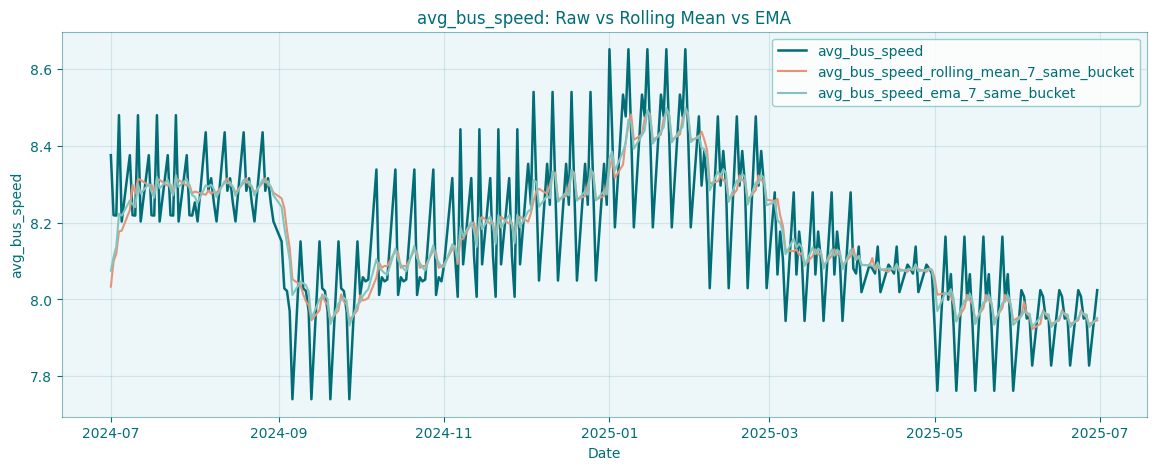

subway_ridership: taxi_zone_id=259, temporal_bucket=weekday_pm_peak
Rows plotted: 261


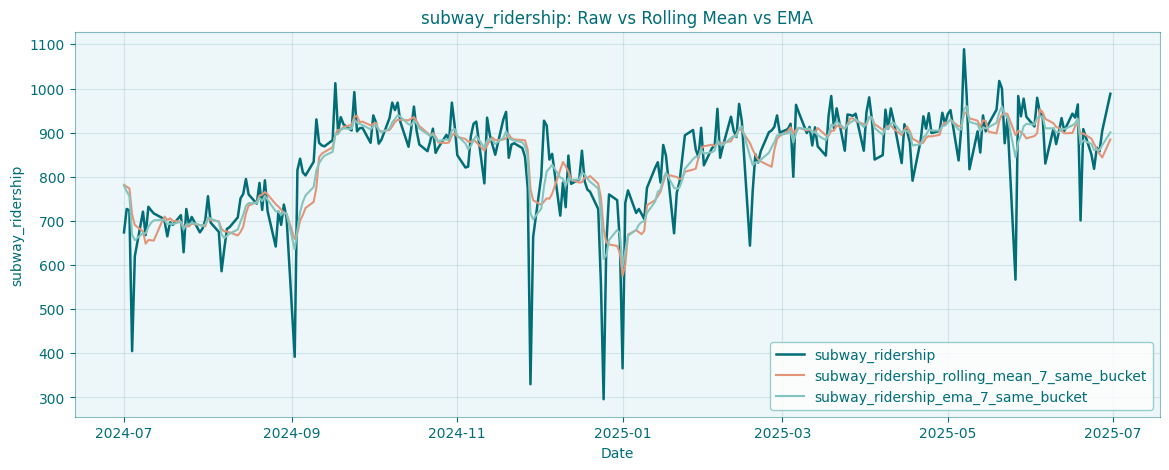

taxi_trip_count: taxi_zone_id=7, temporal_bucket=weekday_am_peak
Rows plotted: 261


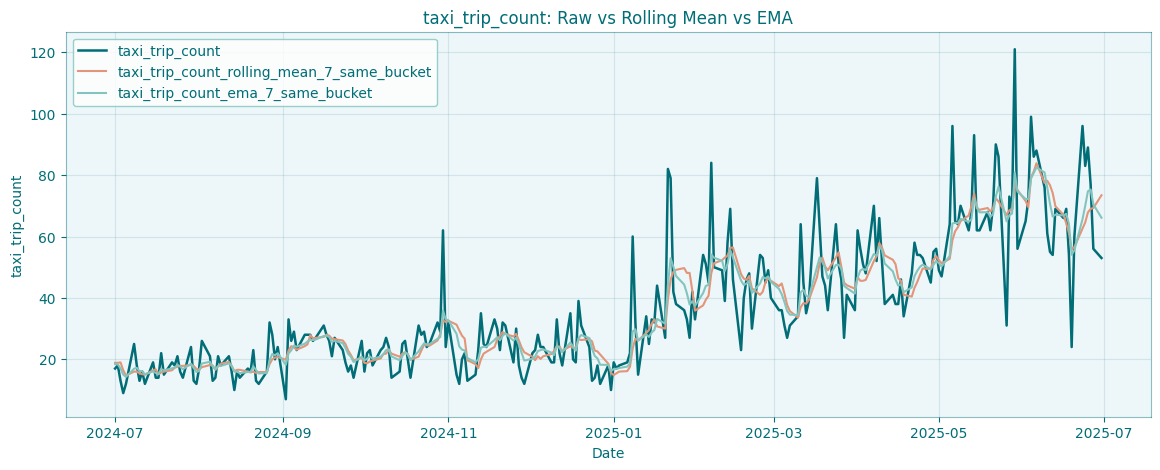

fhvhv_trip_count: taxi_zone_id=7, temporal_bucket=weekday_pm_peak
Rows plotted: 261


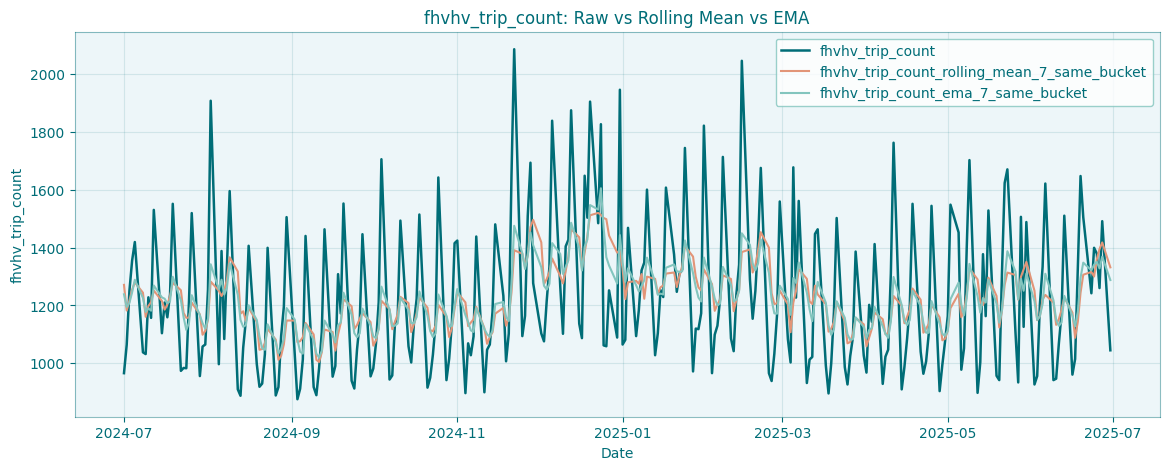

In [45]:
# ---------------------------------------------------------------------
# Plot raw vs smoothing features across representative metrics
# ---------------------------------------------------------------------

SMOOTHING_VISUAL_QA_METRICS = [
    "avg_bus_speed",
    "subway_ridership",
    "taxi_trip_count",
    "fhvhv_trip_count",
]

for i, metric in enumerate(SMOOTHING_VISUAL_QA_METRICS, start=1):

    selected_group_values = select_well_populated_same_bucket_series(
        df=temporal_feature_df,
        metric=metric,
        group_keys=TEMPORAL_GROUP_KEYS,
        top_n_candidates=25,
        random_state=i,
    )

    plot_same_bucket_feature_columns(
        df=temporal_feature_df,
        metric=metric,
        comparison_cols=[
            f"{metric}_rolling_mean_7_same_bucket",
            f"{metric}_ema_7_same_bucket",
        ],
        group_keys=TEMPORAL_GROUP_KEYS,
        sort_key=TEMPORAL_SORT_KEY,
        selected_group_values=selected_group_values,
        start_date="2024-07-01",
        end_date="2025-06-30",
        title_suffix="Raw vs Rolling Mean vs EMA",
    )

Findings\. The visual QA results are encouraging\. Across all four mobility systems, the rolling mean and EMA features behave as expected: both smooth short\-term noise while preserving the broader trend in the underlying metric\. The EMA responds slightly faster to sudden changes, while the rolling mean produces a smoother signal, but the two remain highly consistent overall\. At this stage, the goal is simply to verify that the smoothing logic is working as intended, and these examples suggest that both approaches are successfully capturing underlying mobility trends rather than introducing artifacts\.

🔍 Observation: Several metrics exhibit strong cyclical behavior that remains visible even after smoothing\. The Bus Speed and FHVHV Trip Count examples are especially clear, with a repeating weekly pattern persisting throughout the study period\. This is encouraging because it suggests the feature engineering process is preserving meaningful mobility dynamics while reducing day\-to\-day volatility\. Rather than flattening the signal, the rolling mean and EMA make recurring patterns easier to interpret\.

🔍 Observation: The longer time horizon reveals several structural shifts that would have been invisible in the shorter samples\. Most notably, Taxi Trip Counts exhibit a clear upward shift beginning shortly after the January 2025 congestion pricing launch, with demand remaining elevated for much of the subsequent period\. At the same time, average Bus Speeds trend lower following the policy implementation date, suggesting a meaningful change in underlying travel behavior\. Whether these shifts are ultimately attributable to congestion pricing, broader travel\-demand patterns, or other factors is a question for later analysis, but the smoothing features clearly preserve these longer\-term movements rather than obscuring them\.

### Raw Metric vs Lag Feature

Let’s next verify that the lag features were generated correctly\. A lag feature should simply represent the previous observation from the same Taxi Zone and temporal bucket\. When plotted against the raw metric, the lag series should closely resemble the original series but appear shifted by one observation\. This provides a straightforward visual validation that the lag logic is behaving as intended\.

avg_bus_speed: taxi_zone_id=259, temporal_bucket=weekday_midday
Rows plotted: 261


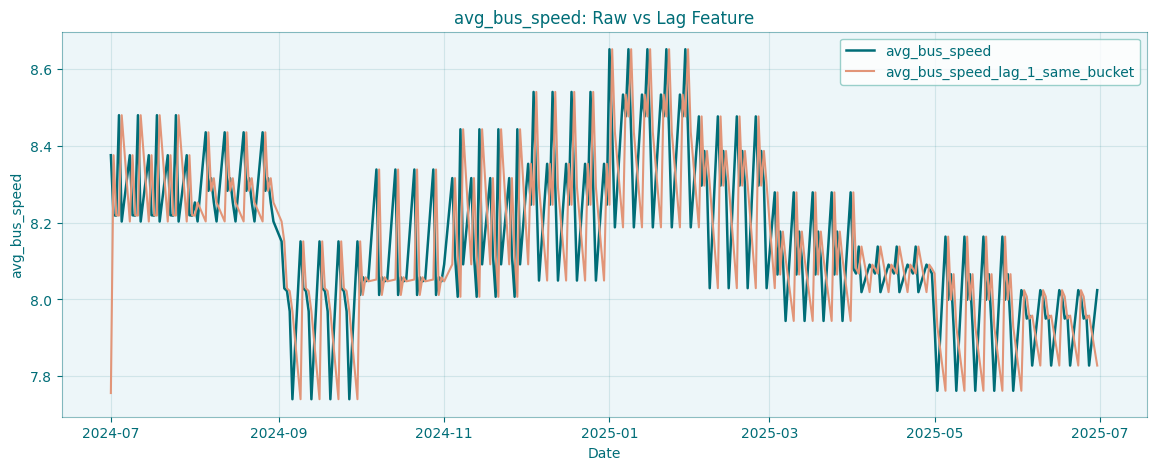

subway_ridership: taxi_zone_id=259, temporal_bucket=weekday_pm_peak
Rows plotted: 261


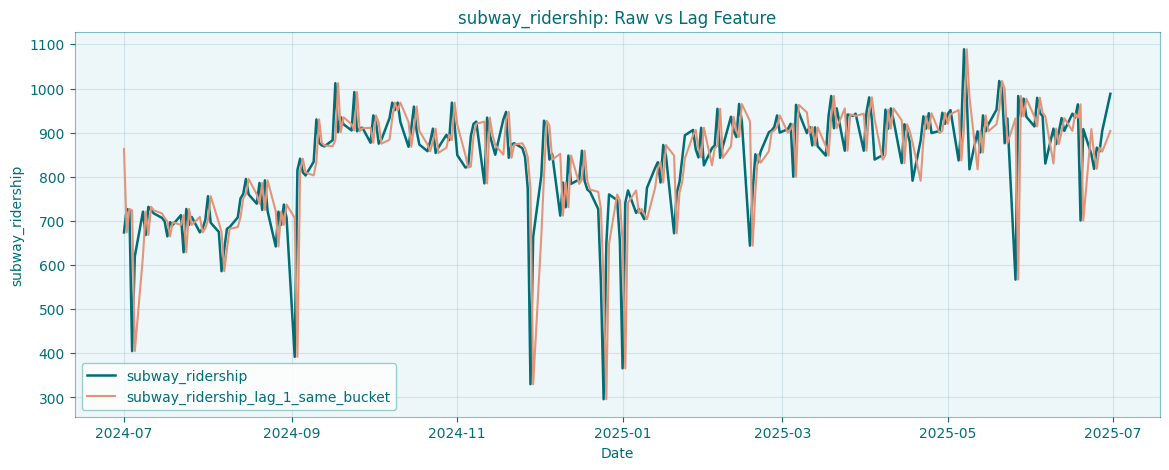

taxi_trip_count: taxi_zone_id=7, temporal_bucket=weekday_am_peak
Rows plotted: 261


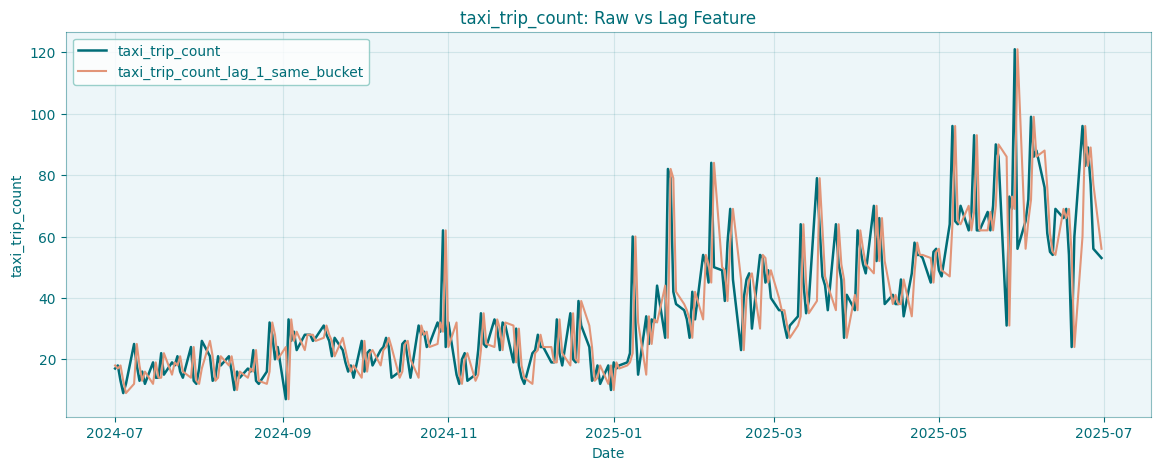

fhvhv_trip_count: taxi_zone_id=7, temporal_bucket=weekday_pm_peak
Rows plotted: 261


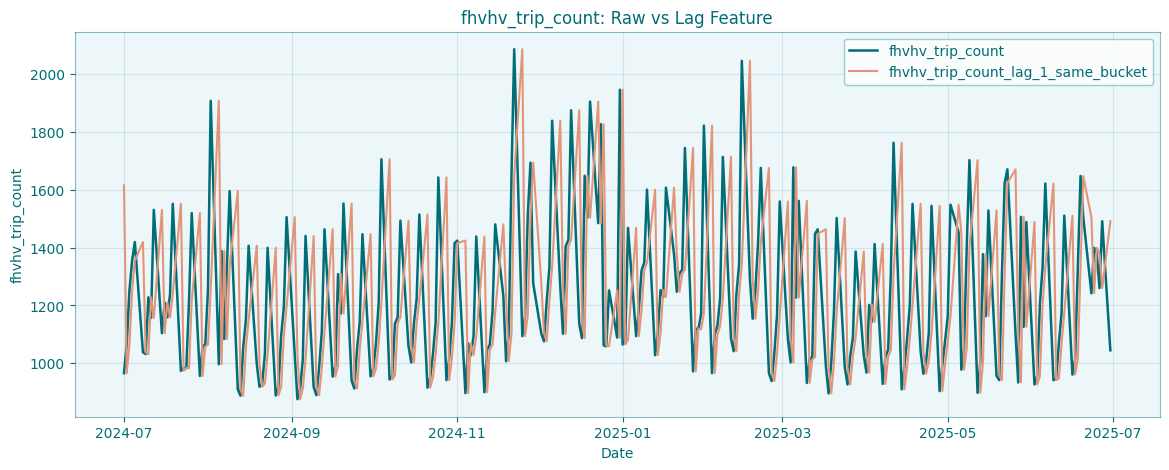

In [46]:
# ---------------------------------------------------------------------
# Plot raw metric vs lag feature
# ---------------------------------------------------------------------

LAG_VISUAL_QA_METRICS = [
    "avg_bus_speed",
    "subway_ridership",
    "taxi_trip_count",
    "fhvhv_trip_count",
]

for i, metric in enumerate(
    LAG_VISUAL_QA_METRICS,
    start=1,
):

    selected_group_values = (
        select_well_populated_same_bucket_series(
            df=temporal_feature_df,
            metric=metric,
            group_keys=TEMPORAL_GROUP_KEYS,
            top_n_candidates=25,
            random_state=i,
        )
    )

    plot_same_bucket_feature_columns(
        df=temporal_feature_df,
        metric=metric,
        comparison_cols=[
            f"{metric}_lag_1_same_bucket",
        ],
        group_keys=TEMPORAL_GROUP_KEYS,
        sort_key=TEMPORAL_SORT_KEY,
        selected_group_values=selected_group_values,
        start_date="2024-07-01",
        end_date="2025-06-30",
        title_suffix="Raw vs Lag Feature",
    )

Findings\. The lag features behave as expected\. Across all four mobility systems, the lagged series closely mirrors the raw metric while appearing shifted by one observation, confirming that the lag logic was implemented correctly\. 

### Raw Metric vs Rolling Std

Let’s check whether the rolling standard deviation features are capturing recent volatility\. The raw metric shows the underlying mobility level, while rolling standard deviation should rise during choppier periods and fall during more stable periods\. This helps validate that the volatility features are responding to real movement in the series rather than producing flat or noisy artifacts\.Standard Deviation

avg_bus_speed: taxi_zone_id=259, temporal_bucket=weekday_midday
Rows plotted: 261


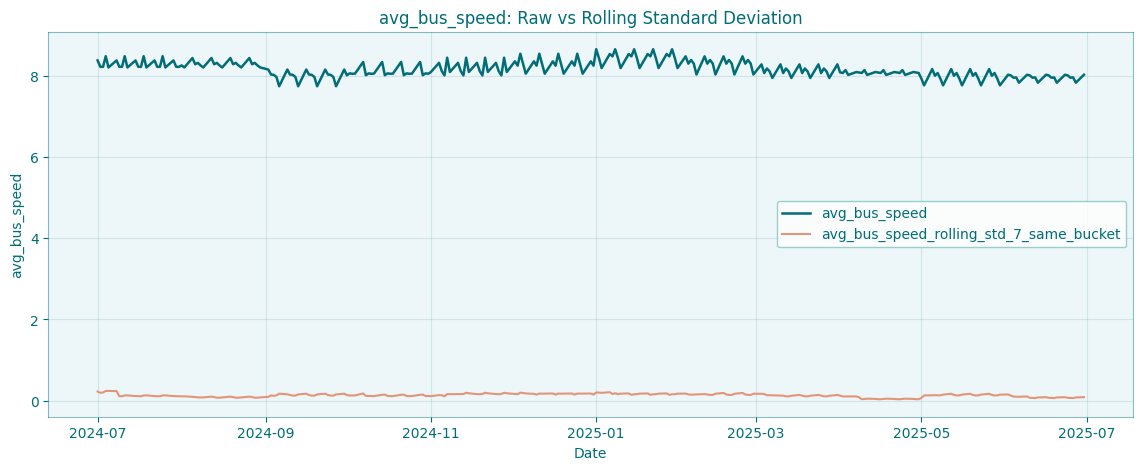

subway_ridership: taxi_zone_id=259, temporal_bucket=weekday_pm_peak
Rows plotted: 261


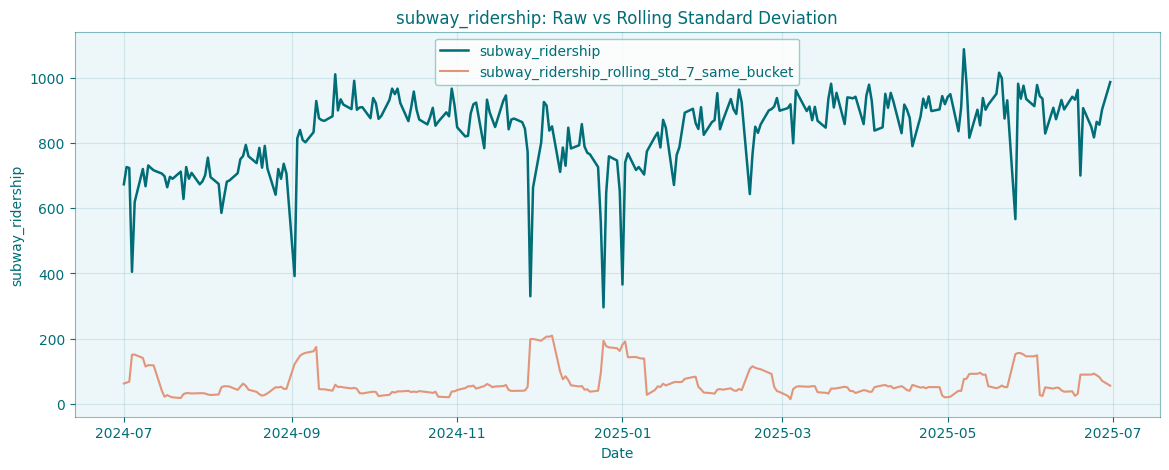

taxi_trip_count: taxi_zone_id=7, temporal_bucket=weekday_am_peak
Rows plotted: 261


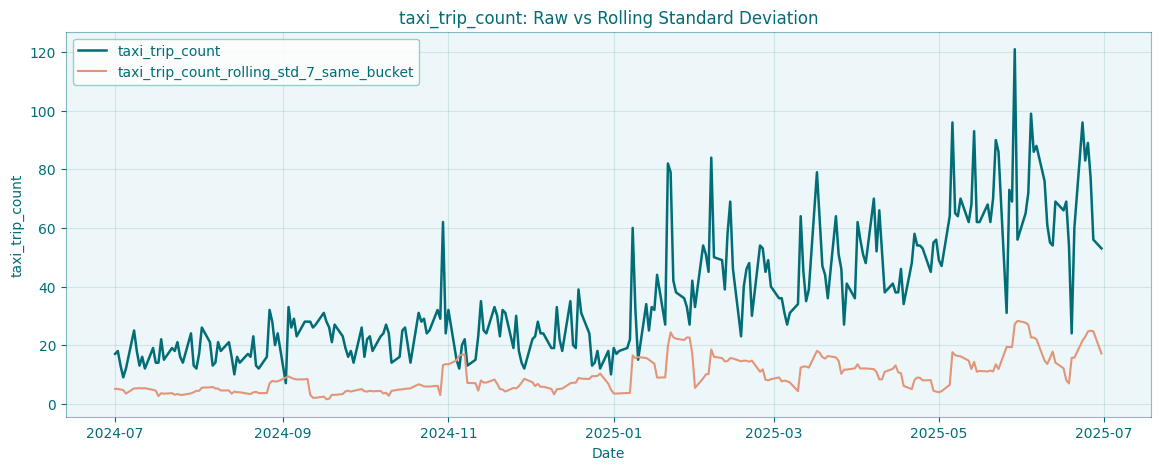

fhvhv_trip_count: taxi_zone_id=7, temporal_bucket=weekday_pm_peak
Rows plotted: 261


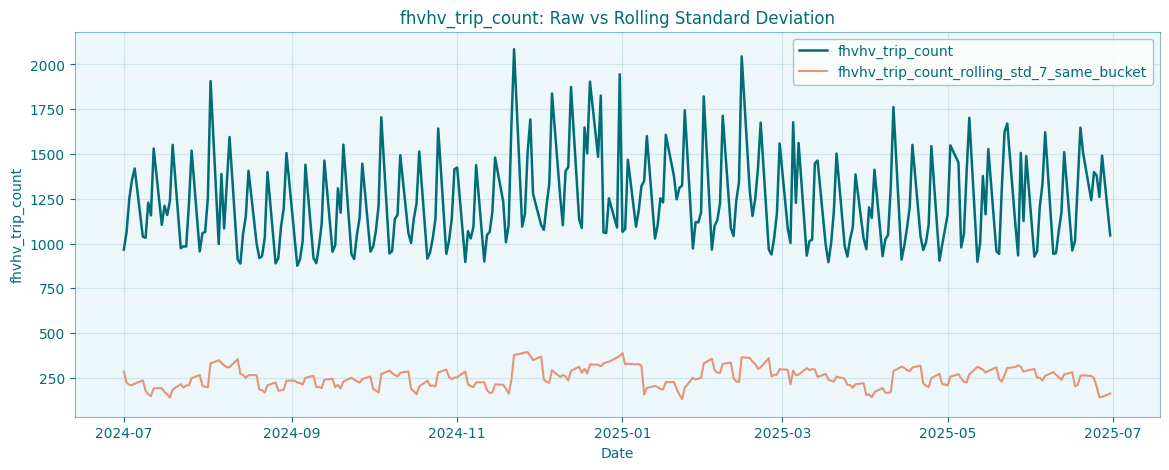

In [47]:
ROLLING_STD_VISUAL_QA_METRICS = [
    "avg_bus_speed",
    "subway_ridership",
    "taxi_trip_count",
    "fhvhv_trip_count",
]

for i, metric in enumerate(ROLLING_STD_VISUAL_QA_METRICS, start=1):

    selected_group_values = select_well_populated_same_bucket_series(
        df=temporal_feature_df,
        metric=metric,
        group_keys=TEMPORAL_GROUP_KEYS,
        top_n_candidates=25,
        random_state=i,
    )

    plot_same_bucket_feature_columns(
        df=temporal_feature_df,
        metric=metric,
        comparison_cols=[
            f"{metric}_rolling_std_7_same_bucket",
        ],
        group_keys=TEMPORAL_GROUP_KEYS,
        sort_key=TEMPORAL_SORT_KEY,
        selected_group_values=selected_group_values,
        start_date="2024-07-01",
        end_date="2025-06-30",
        title_suffix="Raw vs Rolling Standard Deviation",
    )

Findings\. The rolling standard deviation features appear to behave as intended\. Periods of relatively stable mobility activity are associated with lower volatility values, while periods containing larger swings, spikes, or dips produce noticeably higher rolling standard deviations\. Rather than tracking the level of the underlying metric, these features capture the degree of recent variability, providing a complementary signal to the lag and smoothing features\.

🔍 Observation: The volatility features highlight patterns that are difficult to see from the raw metrics alone\. For example, Taxi Trip Counts become noticeably more volatile after January 2025, while Subway Ridership exhibits several concentrated periods of elevated variability driven by sharp ridership drops and rebounds\. These shifts are reflected clearly in the rolling standard deviation series, suggesting that the feature is successfully capturing changes in mobility stability rather than simply mirroring overall activity levels\.

🔍 Observation: Different transportation systems exhibit very different volatility signatures\. Bus Speeds remain relatively stable throughout the period, resulting in consistently low rolling standard deviations, while FHVHV Trip Counts display persistently higher volatility driven by their strong cyclical behavior\. This is encouraging because it suggests the volatility features are responding to the unique characteristics of each mobility system rather than producing a uniform pattern across all metrics\.

### Congestion Pricing Feature Spot Check

Let’s do one final visual QA check for the congestion\-pricing features\. These features should be stable within each Taxi Zone × temporal bucket because they summarize the pre\-CP mean, post\-CP mean, and the difference between those two periods\. This spot check helps confirm that the policy\-change features are behaving like group\-level baselines, not row\-level rolling features\.

In [48]:
# ---------------------------------------------------------------------
# Display congestion pricing feature spot checks
# ---------------------------------------------------------------------

CP_FEATURE_VISUAL_QA_METRICS = [
    "avg_bus_speed",
    "subway_ridership",
    "taxi_trip_count",
    "fhvhv_trip_count",
]

cp_spot_check_rows = []

for i, metric in enumerate(CP_FEATURE_VISUAL_QA_METRICS, start=1):

    selected_group_values = select_well_populated_same_bucket_series(
        df=temporal_feature_df,
        metric=metric,
        group_keys=TEMPORAL_GROUP_KEYS,
        top_n_candidates=25,
        random_state=i,
    )

    group_filter = pd.Series(True, index=temporal_feature_df.index)

    for key, value in zip(TEMPORAL_GROUP_KEYS, selected_group_values):
        group_filter = group_filter & (temporal_feature_df[key] == value)

    cp_cols = [
        f"{metric}_pre_cp_mean_same_bucket",
        f"{metric}_post_cp_mean_same_bucket",
        f"{metric}_cp_abs_delta_same_bucket",
        f"{metric}_cp_pct_delta_same_bucket",
    ]

    cp_group_df = (
        temporal_feature_df
        .loc[
            group_filter,
            [
                *TEMPORAL_GROUP_KEYS,
                "pre_post_cp",
                metric,
                *cp_cols,
            ],
        ]
        .copy()
    )

    cp_spot_check_rows.append({
        "metric": metric,
        "selected_group": dict(zip(TEMPORAL_GROUP_KEYS, selected_group_values)),
        "row_count": len(cp_group_df),
        "pre_cp_rows": (cp_group_df["pre_post_cp"] == "pre_cp").sum(),
        "post_cp_rows": (cp_group_df["pre_post_cp"] == "post_cp").sum(),
        "pre_cp_mean": cp_group_df[cp_cols[0]].iloc[0],
        "post_cp_mean": cp_group_df[cp_cols[1]].iloc[0],
        "cp_abs_delta": cp_group_df[cp_cols[2]].iloc[0],
        "cp_pct_delta": cp_group_df[cp_cols[3]].iloc[0],
        "pre_cp_mean_unique_values": cp_group_df[cp_cols[0]].nunique(dropna=True),
        "post_cp_mean_unique_values": cp_group_df[cp_cols[1]].nunique(dropna=True),
        "cp_abs_delta_unique_values": cp_group_df[cp_cols[2]].nunique(dropna=True),
        "cp_pct_delta_unique_values": cp_group_df[cp_cols[3]].nunique(dropna=True),
    })

cp_spot_check_df = pd.DataFrame(cp_spot_check_rows)

numeric_cols = [
    "pre_cp_mean",
    "post_cp_mean",
    "cp_abs_delta",
    "cp_pct_delta",
]

cp_spot_check_df[numeric_cols] = (
    cp_spot_check_df[numeric_cols]
    .round(3)
)

display(cp_spot_check_df)

,metric,selected_group,row_count,pre_cp_rows,post_cp_rows,pre_cp_mean,post_cp_mean,cp_abs_delta,cp_pct_delta,pre_cp_mean_unique_values,post_cp_mean_unique_values,cp_abs_delta_unique_values,cp_pct_delta_unique_values
0,avg_bus_speed,"{'taxi_zone_id': 259, 'temporal_bucket': 'week...",847,525,322,8.333,8.020,-0.314,-0.038,1,1,1,1
1,subway_ridership,"{'taxi_zone_id': 259, 'temporal_bucket': 'week...",847,525,322,813.061,858.438,45.377,0.056,1,1,1,1
2,taxi_trip_count,"{'taxi_zone_id': 7, 'temporal_bucket': 'weekda...",847,525,322,20.051,64.602,44.551,2.222,1,1,1,1
3,fhvhv_trip_count,"{'taxi_zone_id': 7, 'temporal_bucket': 'weekda...",847,525,322,1186.857,1271.224,84.366,0.071,1,1,1,1


In [49]:
# ---------------------------------------------------------------------
# Assert congestion pricing feature constancy
# ---------------------------------------------------------------------

cp_constancy_cols = [
    "pre_cp_mean_unique_values",
    "post_cp_mean_unique_values",
    "cp_abs_delta_unique_values",
    "cp_pct_delta_unique_values",
]

max_cp_unique_values = (
    cp_spot_check_df[cp_constancy_cols]
    .max()
    .max()
)

assert max_cp_unique_values <= 1, (
    "At least one congestion-pricing feature is not constant within its selected same-bucket group."
)

print("Congestion pricing feature spot check passed.")

Congestion pricing feature spot check passed.


The congestion\-pricing feature spot check passed for all sampled mobility metrics\. Within each Taxi Zone × temporal bucket series, the pre\-CP mean, post\-CP mean, absolute delta, and percentage delta remained constant across all observations, confirming that these features were generated as intended\. This is important because the congestion\-pricing features are designed to represent group\-level baseline comparisons rather than time\-varying measurements\.

🔍 Observation: The sampled series exhibit meaningful variation between their pre\- and post\-congestion\-pricing baselines\. For example, the selected Taxi Trip Count series increased from approximately 21 trips to 66 trips per observation \(\+214%\), while the selected FHVHV series increased by roughly 7%\. Subway Ridership also increased modestly, whereas Bus Speed decreased slightly\. These differences suggest that the congestion\-pricing feature family is capturing real variation across mobility systems rather than producing trivial or near\-zero values\.

### Section Summary

The visual QA checks confirmed that the generated temporal features behave as intended when plotted against real mobility series\. Rolling mean and EMA features smoothed short\-term noise while preserving longer\-term trends, lag features closely tracked the prior same\-bucket observation, and rolling standard deviation features highlighted periods of elevated volatility\. The congestion\-pricing spot check also passed, confirming that pre\-CP and post\-CP means and deltas remain constant within each Taxi Zone × temporal bucket series\. Overall, the visual checks give us confidence that the feature logic is working correctly and that the generated features preserve meaningful mobility patterns without introducing obvious artifacts\.

## 1\.5\.1\.7 Write Temporal Feature Outputs

Persist the enriched mobility panel with temporal features for downstream notebooks\.

In [50]:
# ---------------------------------------------------------------------
# Configure temporal feature outputs
# ---------------------------------------------------------------------

TEMPORAL_FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TEMPORAL_FEATURE_PANEL_OUTPUT_PATH = (
    TEMPORAL_FINAL_DIR / "temporal_mobility_feature_panel.parquet"
)

TEMPORAL_FEATURE_MANIFEST_OUTPUT_PATH = (
    TEMPORAL_FINAL_DIR / "temporal_feature_manifest.csv"
)

TEMPORAL_FEATURE_QA_SUMMARY_OUTPUT_PATH = (
    TEMPORAL_FINAL_DIR / "temporal_feature_qa_summary.csv"
)

print("Temporal feature final output directory:")
print(TEMPORAL_FINAL_DIR)

Temporal feature final output directory:
pipeline_data/1.5.1.final_tables


In [51]:
# ---------------------------------------------------------------------
# Write temporal feature outputs
# ---------------------------------------------------------------------

temporal_feature_df.to_parquet(
    TEMPORAL_FEATURE_PANEL_OUTPUT_PATH,
    index=False,
)

temporal_feature_manifest_df.to_csv(
    TEMPORAL_FEATURE_MANIFEST_OUTPUT_PATH,
    index=False,
)

feature_qa_summary_df.to_csv(
    TEMPORAL_FEATURE_QA_SUMMARY_OUTPUT_PATH,
    index=False,
)

print("Wrote temporal feature panel:")
print(TEMPORAL_FEATURE_PANEL_OUTPUT_PATH)

print("Wrote temporal feature manifest:")
print(TEMPORAL_FEATURE_MANIFEST_OUTPUT_PATH)

print("Wrote temporal feature QA summary:")
print(TEMPORAL_FEATURE_QA_SUMMARY_OUTPUT_PATH)

Wrote temporal feature panel:
pipeline_data/1.5.1.final_tables/temporal_mobility_feature_panel.parquet
Wrote temporal feature manifest:
pipeline_data/1.5.1.final_tables/temporal_feature_manifest.csv
Wrote temporal feature QA summary:
pipeline_data/1.5.1.final_tables/temporal_feature_qa_summary.csv


In [52]:
# ---------------------------------------------------------------------
# Validate temporal feature outputs
# ---------------------------------------------------------------------

temporal_feature_output_inventory_df = pd.DataFrame({
    "output_name": [
        "temporal_feature_panel",
        "temporal_feature_manifest",
        "temporal_feature_qa_summary",
    ],
    "output_path": [
        TEMPORAL_FEATURE_PANEL_OUTPUT_PATH,
        TEMPORAL_FEATURE_MANIFEST_OUTPUT_PATH,
        TEMPORAL_FEATURE_QA_SUMMARY_OUTPUT_PATH,
    ],
})

temporal_feature_output_inventory_df["file_exists"] = (
    temporal_feature_output_inventory_df["output_path"]
    .apply(lambda path: path.exists())
)

temporal_feature_output_inventory_df["file_size_mb"] = (
    temporal_feature_output_inventory_df["output_path"]
    .apply(
        lambda path: path.stat().st_size / (1024 ** 2)
        if path.exists()
        else 0
    )
    .round(3)
)

display(temporal_feature_output_inventory_df)

assert temporal_feature_output_inventory_df["file_exists"].all(), (
    "One or more temporal feature outputs were not written successfully."
)

print("Temporal feature output validation passed.")

,output_name,output_path,file_exists,file_size_mb
0,temporal_feature_panel,pipeline_data/1.5.1.final_tables/temporal_mobi...,True,760.501
1,temporal_feature_manifest,pipeline_data/1.5.1.final_tables/temporal_feat...,True,0.031
2,temporal_feature_qa_summary,pipeline_data/1.5.1.final_tables/temporal_feat...,True,0.015


Temporal feature output validation passed.


In [53]:
# ---------------------------------------------------------------------
# Cleanup notebook memory
# ---------------------------------------------------------------------

import gc

large_objects_to_delete = [
    "mobility_df",
    "temporal_feature_df",
    "function_test_df",
    "feature_qa_detail_df",
    "feature_qa_summary_df",
    "temporal_feature_manifest_df",
    "temporal_feature_output_inventory_df",
]

for object_name in large_objects_to_delete:
    if object_name in globals():
        del globals()[object_name]

gc.collect()

print("1.5.1 memory cleanup complete.")

1.5.1 memory cleanup complete.


## Close

This notebook completed the first major phase of mobility feature engineering for the project\. Starting from the harmonized mobility panel, we generated temporal features capturing recent mobility conditions, short\-term trends, volatility, and congestion\-pricing baseline differences across Bus, Subway, Taxi, and FHVHV systems\. Extensive statistical and visual QA confirmed that the generated features behave as intended and that previously identified TLC data quality issues were successfully resolved before feature generation\. The resulting enriched mobility panel and accompanying feature manifest provide the foundation for the next stage of the project, where we will begin evaluating feature usefulness, reducing redundancy, and preparing inputs for clustering, anomaly detection, and congestion\-pricing analysis\.

In [54]:
# ---------------------------------------------------------------------
# Archived TLC repair QA: cleanup propagation into 1.5.1 output
# ---------------------------------------------------------------------
# This was used during the TLC cleanup repair pass. It is intentionally
# commented out so a full Run Notebook does not execute debug QA after
# the notebook Close section.
#
# To rerun manually, uncomment this cell after the 1.5.1 temporal feature
# panel has been written.
#
# from pathlib import Path
# import duckdb
#
# PIPELINE_DATA_DIR = Path("pipeline_data")
# OUTPUT_PANEL_PATH = PIPELINE_DATA_DIR / "1.5.1.final_tables" / "temporal_mobility_feature_panel.parquet"
#
# MIN_VALID_TLC_TRIP_DURATION_SECONDS = 60
# MAX_VALID_TLC_TRIP_DURATION_SECONDS = 86_400
# MIN_VALID_TLC_TRIP_DISTANCE = 0
# MAX_VALID_TLC_TRIP_DISTANCE = 100
# MAX_VALID_TLC_TRIP_SPEED_MPH = 100
#
# tlc_cleanup_downstream_qa_df = duckdb.sql(f"""
#     SELECT
#         COUNT(*) AS row_count,
#         SUM(CASE WHEN taxi_trip_count > 0 AND taxi_avg_trip_duration < {MIN_VALID_TLC_TRIP_DURATION_SECONDS} THEN 1 ELSE 0 END)
#             AS short_taxi_duration_rows,
#         SUM(CASE WHEN taxi_trip_count > 0 AND taxi_avg_trip_duration > {MAX_VALID_TLC_TRIP_DURATION_SECONDS} THEN 1 ELSE 0 END)
#             AS excessive_taxi_duration_rows,
#         SUM(CASE WHEN taxi_trip_count > 0 AND taxi_avg_trip_distance < {MIN_VALID_TLC_TRIP_DISTANCE} THEN 1 ELSE 0 END)
#             AS negative_taxi_distance_rows,
#         SUM(CASE WHEN taxi_trip_count > 0 AND taxi_avg_trip_distance > {MAX_VALID_TLC_TRIP_DISTANCE} THEN 1 ELSE 0 END)
#             AS excessive_taxi_distance_rows,
#         SUM(CASE WHEN taxi_trip_count > 0 AND taxi_avg_trip_speed > {MAX_VALID_TLC_TRIP_SPEED_MPH} THEN 1 ELSE 0 END)
#             AS excessive_taxi_speed_rows,
#         SUM(CASE WHEN fhvhv_trip_count > 0 AND fhvhv_avg_trip_duration < {MIN_VALID_TLC_TRIP_DURATION_SECONDS} THEN 1 ELSE 0 END)
#             AS short_fhvhv_duration_rows,
#         SUM(CASE WHEN fhvhv_trip_count > 0 AND fhvhv_avg_trip_duration > {MAX_VALID_TLC_TRIP_DURATION_SECONDS} THEN 1 ELSE 0 END)
#             AS excessive_fhvhv_duration_rows,
#         SUM(CASE WHEN fhvhv_trip_count > 0 AND fhvhv_avg_trip_distance < {MIN_VALID_TLC_TRIP_DISTANCE} THEN 1 ELSE 0 END)
#             AS negative_fhvhv_distance_rows,
#         SUM(CASE WHEN fhvhv_trip_count > 0 AND fhvhv_avg_trip_distance > {MAX_VALID_TLC_TRIP_DISTANCE} THEN 1 ELSE 0 END)
#             AS excessive_fhvhv_distance_rows,
#         SUM(CASE WHEN fhvhv_trip_count > 0 AND fhvhv_avg_trip_speed > {MAX_VALID_TLC_TRIP_SPEED_MPH} THEN 1 ELSE 0 END)
#             AS excessive_fhvhv_speed_rows
#     FROM read_parquet('{OUTPUT_PANEL_PATH.as_posix()}')
# """).df()
#
# display(tlc_cleanup_downstream_qa_df)
#
# invalid_tlc_cleanup_rows = (
#     tlc_cleanup_downstream_qa_df.drop(columns=["row_count"]).sum().sum()
# )
#
# assert invalid_tlc_cleanup_rows == 0, (
#     "TLC cleanup did not propagate cleanly into this notebook output."
# )
#
# print("TLC cleanup propagation QA passed.")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>